In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [66]:
skills    = pd.read_excel("Academic_Skills.xlsx")
placement = pd.read_excel("Placement_Record.xlsx")
profile   = pd.read_excel("Student_Profile.xlsx")

In [67]:
                                                            #DATA UNDERSTANDING--- SKILLS
skills.head()

,Student_ID,Quantitative_Score,Logical_Score,Technical_Score,Soft_Skills_Score,Projects_Completed,Hackathon_Participation,Extra_Curricular_Score
0,S19715,67.00,91.00,58.00,6,4,No,4
1,S45666,79.33,78.33,77.48,5,2,No,8
2,S43486,65.00,68.00,64.00,7,1,Yes,8
3,S34918,56.00,52.00,52.00,9,3,No,9
4,S13869,85.80,73.60,73.30,7,2,No,5


In [68]:
skills.tail()

,Student_ID,Quantitative_Score,Logical_Score,Technical_Score,Soft_Skills_Score,Projects_Completed,Hackathon_Participation,Extra_Curricular_Score
15210,S49071,1258.0,NaN,24.4,8,7,No,7
15211,S28678,1032.0,NaN,37.3,6,9,Yes,4
15212,S42781,1299.0,NaN,25.2,6,5,Yes,6
15213,S49686,1038.0,NaN,39.4,5,4,Yes,6
15214,S98170,1145.0,NaN,31.9,5,6,No,9


In [69]:
skills.shape

(15215, 8)

In [70]:
skills.columns

Index(['Student_ID', 'Quantitative_Score', 'Logical_Score', 'Technical_Score',
       'Soft_Skills_Score', 'Projects_Completed', 'Hackathon_Participation',
       'Extra_Curricular_Score'],
      dtype='object')

In [71]:
skills.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15215 entries, 0 to 15214
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               15215 non-null  object 
 1   Quantitative_Score       15215 non-null  float64
 2   Logical_Score            215 non-null    float64
 3   Technical_Score          15215 non-null  float64
 4   Soft_Skills_Score        15215 non-null  int64  
 5   Projects_Completed       15215 non-null  int64  
 6   Hackathon_Participation  15215 non-null  object 
 7   Extra_Curricular_Score   15215 non-null  int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 951.1+ KB


In [72]:
skills.describe()

,Quantitative_Score,Logical_Score,Technical_Score,Soft_Skills_Score,Projects_Completed,Extra_Curricular_Score
count,15215.000000,215.000000,15215.000000,15215.000000,15215.000000,15215.000000
mean,465.207311,66.333163,61.457245,4.422149,2.860598,5.829773
std,563.966190,10.897509,22.768441,1.890793,2.156389,2.315026
min,40.890000,37.000000,20.000000,1.000000,0.000000,1.000000
25%,77.000000,60.900000,35.400000,4.000000,1.000000,4.000000
50%,87.000000,65.000000,74.000000,4.000000,2.000000,6.000000
75%,1069.000000,73.000000,80.000000,4.000000,3.000000,8.000000
max,1600.000000,97.700000,91.000000,10.000000,9.000000,10.000000


In [73]:
                                                             #HANDLING MISSING VALUES
skills.isnull().sum()

Student_ID                     0
Quantitative_Score             0
Logical_Score              15000
Technical_Score                0
Soft_Skills_Score              0
Projects_Completed             0
Hackathon_Participation        0
Extra_Curricular_Score         0
dtype: int64

In [74]:
skills.drop(columns=['Logical_Score'], inplace=True)

In [75]:
skills.isnull().sum()

Student_ID                 0
Quantitative_Score         0
Technical_Score            0
Soft_Skills_Score          0
Projects_Completed         0
Hackathon_Participation    0
Extra_Curricular_Score     0
dtype: int64

In [76]:
                                                                     #DUPLICATES
skills.duplicated().sum()

0

In [77]:
skills['Hackathon_Participation'].value_counts()

No     10546
Yes     4669
Name: Hackathon_Participation, dtype: int64

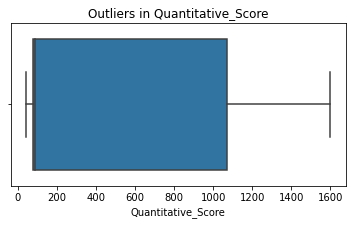

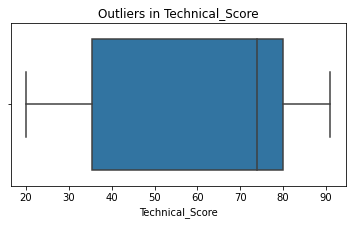

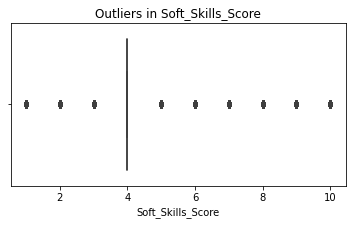

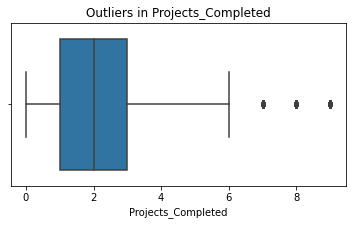

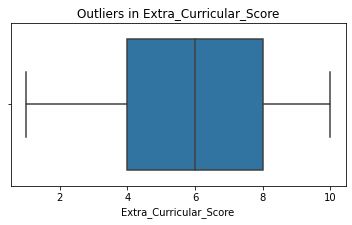

In [78]:
# Outliers 
numeric_cols = [
    'Quantitative_Score',
    'Technical_Score',
    'Soft_Skills_Score',
    'Projects_Completed',
    'Extra_Curricular_Score'
]

import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=skills[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [79]:
# INSIGHTS - Academic_Skills Missing Values
# 1. Logical_Score had 15,000 missing values out of 15,215 (98.6%) → Dropped the column
# 2. All other columns had 0 missing values → No further action needed
# 3. No duplicate records found (0 duplicates)
# 4. Final cleaned shape: (15215, 7) — 7 columns remaining after drop
# 5. No outlier treatment was applied beacuse the boxplot analysis showed a few higher values in soft skills core and projects completed,but these represent genuine varaition in student performance.

In [80]:
                                                               #DATA UNDERSTANDING
placement.head()

,Placement_ID,Student_ID,Company_Name,Industry_Sector,Job_Role,CTC_LPA,Placement_Status,Placement_Type,Interview_Rounds_Cleared,Offer_Accepted,Placement_Date
0,P00001,S25851,Wipro,IT,Software Engineer,2.70,Placed,On-Campus,4,Yes,2024-06-21
1,P00002,S90782,KPMG,Consulting,Software Engineer,2.00,Placed,On-Campus,4,Yes,2021-02-19
2,P00003,S95943,TCS,IT,HR Trainee,2.50,Placed,On-Campus,1,Yes,2023-01-29
3,P00004,S87753,KPMG,Consulting,Software Engineer,0.00,Not Placed,On-Campus,4,No,2020-03-30
4,P00005,S47378,Flipkart,E-Commerce,Business Analyst,4.25,Placed,On-Campus,4,Yes,2023-02-24


In [81]:
placement.tail()

,Placement_ID,Student_ID,Company_Name,Industry_Sector,Job_Role,CTC_LPA,Placement_Status,Placement_Type,Interview_Rounds_Cleared,Offer_Accepted,Placement_Date
15210,P15211,S32440,KPMG,Consulting,Consultant,0.315,Placed,Off-Campus,3,Yes,2022-02-05
15211,P15212,S54693,Wipro,IT,Developer,0.418,Placed,Off-Campus,1,Yes,2021-06-03
15212,P15213,S39239,HCL,IT,Consultant,0.495,Placed,Off-Campus,1,Yes,2020-06-16
15213,P15214,S93038,TCS,IT,Business Analyst,0.547,Placed,Off-Campus,2,Yes,2024-05-30
15214,P15215,S36636,EY,Consulting,Developer,0.570,Placed,Off-Campus,3,Yes,2024-08-17


In [82]:
placement.shape

(15215, 11)

In [83]:
placement.columns

Index(['Placement_ID', 'Student_ID', 'Company_Name', 'Industry_Sector',
       'Job_Role', 'CTC_LPA', 'Placement_Status', 'Placement_Type',
       'Interview_Rounds_Cleared', 'Offer_Accepted', 'Placement_Date'],
      dtype='object')

In [84]:
placement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15215 entries, 0 to 15214
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Placement_ID              15215 non-null  object        
 1   Student_ID                15215 non-null  object        
 2   Company_Name              15215 non-null  object        
 3   Industry_Sector           15215 non-null  object        
 4   Job_Role                  15215 non-null  object        
 5   CTC_LPA                   5215 non-null   float64       
 6   Placement_Status          9412 non-null   object        
 7   Placement_Type            15215 non-null  object        
 8   Interview_Rounds_Cleared  15215 non-null  int64         
 9   Offer_Accepted            9412 non-null   object        
 10  Placement_Date            15215 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 1.3+ MB


In [85]:
placement.describe()

,CTC_LPA,Interview_Rounds_Cleared
count,5215.000000,15215.000000
mean,0.566709,2.742425
std,0.453026,0.983282
min,0.000000,1.000000
25%,0.400000,2.000000
50%,0.507000,3.000000
75%,0.614000,3.000000
max,9.400000,5.000000


In [86]:
                                                                  #MISSING VALUES 
placement.isnull().sum()

Placement_ID                    0
Student_ID                      0
Company_Name                    0
Industry_Sector                 0
Job_Role                        0
CTC_LPA                     10000
Placement_Status             5803
Placement_Type                  0
Interview_Rounds_Cleared        0
Offer_Accepted               5803
Placement_Date                  0
dtype: int64

In [87]:
print(placement['Placement_Status'].value_counts(dropna=False))
print(placement['Placement_Type'].value_counts())
print(placement['Offer_Accepted'].value_counts(dropna=False))

Placed        8497
NaN           5803
Not Placed     915
Name: Placement_Status, dtype: int64
On-Campus     10215
Off-Campus     5000
Name: Placement_Type, dtype: int64
Yes    8497
NaN    5803
No      915
Name: Offer_Accepted, dtype: int64


In [88]:
placement['Placement_Status'] = placement['Placement_Status'].fillna('Not Placed')
placement['Offer_Accepted'] = placement['Offer_Accepted'].fillna('No')
placement['CTC_LPA'] = placement['CTC_LPA'].fillna(0)

In [89]:
placement.isnull().sum()

Placement_ID                0
Student_ID                  0
Company_Name                0
Industry_Sector             0
Job_Role                    0
CTC_LPA                     0
Placement_Status            0
Placement_Type              0
Interview_Rounds_Cleared    0
Offer_Accepted              0
Placement_Date              0
dtype: int64

In [90]:
                                                                        # DUPLICATES 
placement.duplicated().sum()

0

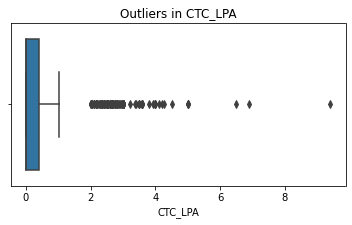

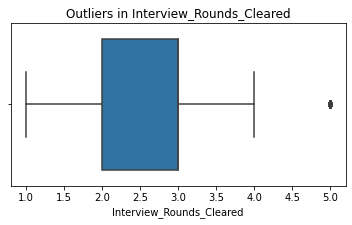

In [91]:
                                                         # Outlier Detection for Placement Dataset

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['CTC_LPA', 'Interview_Rounds_Cleared']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=placement[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [92]:
placement[['CTC_LPA','Interview_Rounds_Cleared']].describe()

,CTC_LPA,Interview_Rounds_Cleared
count,15215.000000,15215.000000
mean,0.194242,2.742425
std,0.377742,0.983282
min,0.000000,1.000000
25%,0.000000,2.000000
50%,0.000000,3.000000
75%,0.410000,3.000000
max,9.400000,5.000000


In [93]:
# INSIGHTS - Placement_Record Missing Values
# 1. CTC_LPA had 10,000 missing values → Filled with 0 (no salary for unplaced students)
# 2. Placement_Status had 5,803 missing values → Filled with 'Not Placed'
# 3. Offer_Accepted had 5,803 missing values → Filled with 'No'
# 4. Placement_Status & Offer_Accepted had same 5803 missing rows (same students)
# 5. No duplicate records found (0 duplicates)
# 6. Outlier analysis was performed on CTC_LPA and Interview_Rounds_Cleared using boxplots; no significant outliers were detected.

In [94]:
                                                                 #PROFILE DATASET

In [95]:
                                                               #DATA UNDERSTANDING 
profile.head()

,Student_ID,Gender,Age,Department,Degree,College_Region,CGPA,Attendance_%,Internship_Completed,Certifications_Count,Communication_Score
0,S25851,Male,24,Commerce,B.Tech,South,58.80,93,No,0,7
1,S90782,Male,22,Science,MBA,South,66.28,96,Yes,0,6
2,S95943,Male,25,Arts,BBA,East,57.80,81,No,0,9
3,S87753,Male,25,Science,MBA,East,59.43,79,No,0,7
4,S47378,Male,21,Commerce,MCA,East,55.50,93,No,0,8


In [96]:
profile.tail()

,Student_ID,Gender,Age,Department,Degree,College_Region,CGPA,Attendance_%,Internship_Completed,Certifications_Count,Communication_Score
15210,S32440,Female,26,Arts,BCA,South,2.44,78,NaN,3,5
15211,S54693,Female,18,Law,BCA,North,3.73,76,No,3,4
15212,S39239,Female,19,Law,BCA,North,2.52,90,NaN,5,2
15213,S93038,Male,19,Law,BBA,East,3.94,95,Yes,5,1
15214,S36636,Female,23,Computer Science,B.Tech,East,3.19,82,NaN,0,8


In [97]:
profile.shape

(15215, 11)

In [98]:
profile.columns

Index(['Student_ID', 'Gender', 'Age', 'Department', 'Degree', 'College_Region',
       'CGPA', 'Attendance_%', 'Internship_Completed', 'Certifications_Count',
       'Communication_Score'],
      dtype='object')

In [99]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15215 entries, 0 to 15214
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            15215 non-null  object 
 1   Gender                15215 non-null  object 
 2   Age                   15215 non-null  int64  
 3   Department            5215 non-null   object 
 4   Degree                15215 non-null  object 
 5   College_Region        15215 non-null  object 
 6   CGPA                  15215 non-null  float64
 7   Attendance_%          15215 non-null  int64  
 8   Internship_Completed  12253 non-null  object 
 9   Certifications_Count  15215 non-null  int64  
 10  Communication_Score   15215 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 1.3+ MB


In [100]:
profile.describe()

,Age,CGPA,Attendance_%,Certifications_Count,Communication_Score
count,15215.000000,15215.000000,15215.000000,15215.000000,15215.000000
mean,22.821952,6.931978,87.424055,1.491489,4.419389
std,2.473318,7.039913,7.472231,1.419424,1.888207
min,18.000000,2.000000,75.000000,0.000000,1.000000
25%,21.000000,3.540000,81.000000,0.000000,4.000000
50%,23.000000,7.400000,87.000000,1.000000,4.000000
75%,24.500000,8.000000,94.000000,2.000000,4.000000
max,29.000000,77.890000,100.000000,5.000000,10.000000


In [101]:
                                                             #HANDLING MISSING VALUES
profile.isnull().sum()

Student_ID                  0
Gender                      0
Age                         0
Department              10000
Degree                      0
College_Region              0
CGPA                        0
Attendance_%                0
Internship_Completed     2962
Certifications_Count        0
Communication_Score         0
dtype: int64

In [102]:
(profile['Department'].value_counts(dropna=False))

NaN                 10000
Arts                  760
Mathematics           745
Law                   727
Business              719
Engineering           701
Medicine              689
Computer Science      670
Commerce              113
Science                91
Name: Department, dtype: int64

In [103]:
(profile['Internship_Completed'].value_counts(dropna=False))

Yes    9129
No     3124
NaN    2962
Name: Internship_Completed, dtype: int64

In [104]:
profile['Internship_Completed'] = profile['Internship_Completed'].fillna('No')

In [105]:
profile['Department'] = profile['Department'].fillna('Unknown')

In [106]:
profile.isnull().sum()

Student_ID              0
Gender                  0
Age                     0
Department              0
Degree                  0
College_Region          0
CGPA                    0
Attendance_%            0
Internship_Completed    0
Certifications_Count    0
Communication_Score     0
dtype: int64

In [107]:
                                                                     # DUPLICATES
profile.duplicated().sum()

0

In [108]:
profile['CGPA'].describe()

count    15215.000000
mean         6.931978
std          7.039913
min          2.000000
25%          3.540000
50%          7.400000
75%          8.000000
max         77.890000
Name: CGPA, dtype: float64

In [109]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15215 entries, 0 to 15214
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            15215 non-null  object 
 1   Gender                15215 non-null  object 
 2   Age                   15215 non-null  int64  
 3   Department            15215 non-null  object 
 4   Degree                15215 non-null  object 
 5   College_Region        15215 non-null  object 
 6   CGPA                  15215 non-null  float64
 7   Attendance_%          15215 non-null  int64  
 8   Internship_Completed  15215 non-null  object 
 9   Certifications_Count  15215 non-null  int64  
 10  Communication_Score   15215 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 1.3+ MB


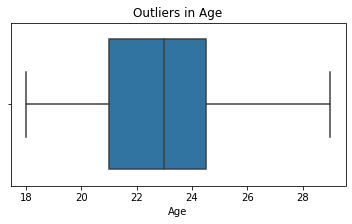

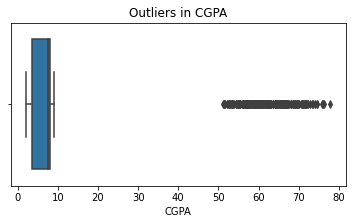

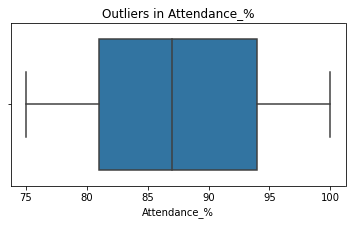

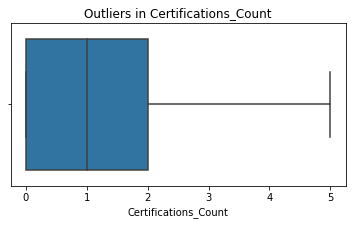

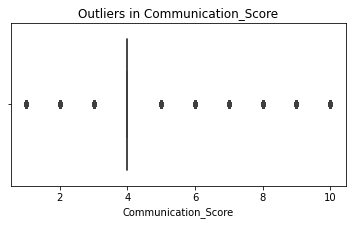

In [110]:
# Outlier Detection - Student_Profile Dataset

import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'Age',
    'CGPA',
    'Attendance_%',
    'Certifications_Count',
    'Communication_Score'
]

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=profile[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [111]:
profile = profile[(profile['CGPA'] >= 0) & (profile['CGPA'] <= 10)]

In [112]:
profile['CGPA'].describe()

count    15000.000000
mean         6.138683
std          2.290653
min          2.000000
25%          3.510000
50%          7.400000
75%          8.000000
max          9.100000
Name: CGPA, dtype: float64

In [113]:
# INSIGHTS - Student_Profile Missing Values
# 1. Department had 10,000 missing values → Filled with 'Unknown'
# 2. Internship_Completed had 2,962 missing values → Filled with 'No'
# 3. CGPA has outliers (max 77.89) → Will be treated in EDA phase with IQR/boxplot
# 4. No duplicate records found (0 duplicates)
# 5. All 3 datasets are now cleaned and ready for merging
# 6. Outlier analysis revealed unrealistic CGPA values exceeding the valid 0–10 range; these records were removed to maintain data accuracy.
# 7. Communication_Score showed a sparse distribution with many zero values, but no abnormal outliers were detected.

In [114]:
                                                                   # MERGING 

In [115]:
profile_clean = profile.drop_duplicates(subset='Student_ID', keep='first')
skills_clean = skills.drop_duplicates(subset='Student_ID', keep='first')
placement_clean = placement.drop_duplicates(subset='Student_ID', keep='first')

print(profile_clean.shape)
print(skills_clean.shape)
print(placement_clean.shape)

(13791, 11)
(13976, 7)
(13971, 11)


In [116]:
master = profile_clean.merge(skills_clean, on='Student_ID', how='left')
master = master.merge(placement_clean, on='Student_ID', how='left')
master.shape

(13791, 27)

In [117]:
skill_cols = ['Quantitative_Score', 'Technical_Score', 'Soft_Skills_Score', 
              'Projects_Completed', 'Hackathon_Participation', 'Extra_Curricular_Score']
master[skill_cols] = master[skill_cols].fillna(0)

In [118]:
master.isnull().sum()

Student_ID                  0
Gender                      0
Age                         0
Department                  0
Degree                      0
College_Region              0
CGPA                        0
Attendance_%                0
Internship_Completed        0
Certifications_Count        0
Communication_Score         0
Quantitative_Score          0
Technical_Score             0
Soft_Skills_Score           0
Projects_Completed          0
Hackathon_Participation     0
Extra_Curricular_Score      0
Placement_ID                0
Company_Name                0
Industry_Sector             0
Job_Role                    0
CTC_LPA                     0
Placement_Status            0
Placement_Type              0
Interview_Rounds_Cleared    0
Offer_Accepted              0
Placement_Date              0
dtype: int64

In [119]:
master.shape

(13791, 27)

In [120]:
                                                                    # SQL CONNECTION

In [121]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///niit_edu.db")
print("✅ Connected to SQLite!")

# Save tables to database
profile_clean.to_sql('student_profile', con=engine, if_exists='replace', index=False)
skills_clean.to_sql('academic_skills', con=engine, if_exists='replace', index=False)
placement_clean.to_sql('placement_record', con=engine, if_exists='replace', index=False)
master.to_sql('master_data', con=engine, if_exists='replace', index=False)

print("✅ All tables saved!")

# Test it
pd.read_sql("SELECT COUNT(*) FROM master_data", engine)

✅ Connected to SQLite!
✅ All tables saved!


,COUNT(*)
0,13791


In [122]:
profile_clean.to_sql('student_profile', con=engine, if_exists='replace', index=False)

13791

In [123]:
skills_clean.to_sql('academic_skills', con=engine, if_exists='replace', index=False)

13976

In [124]:
placement_clean.to_sql('placement_record', con=engine, if_exists='replace', index=False)

13971

In [125]:
master.to_sql('master_data', con=engine, if_exists='replace', index=False)

13791

In [126]:
pd.read_sql("SELECT COUNT(*) FROM master_data", engine)

,COUNT(*)
0,13791


In [127]:
master.head()

,Student_ID,Gender,Age,Department,Degree,College_Region,CGPA,Attendance_%,Internship_Completed,Certifications_Count,...,Placement_ID,Company_Name,Industry_Sector,Job_Role,CTC_LPA,Placement_Status,Placement_Type,Interview_Rounds_Cleared,Offer_Accepted,Placement_Date
0,S33706,Male,22,Unknown,MBA,South,7.5,96,Yes,1,...,P00216,KPMG,Consulting,Developer,0.0,Not Placed,On-Campus,5,No,2021-07-21
1,S70926,Female,24,Unknown,B.Tech,South,8.9,80,No,2,...,P00217,HCL,IT,Developer,0.0,Placed,On-Campus,3,Yes,2025-03-21
2,S13445,Male,23,Unknown,B.Tech,South,7.3,81,Yes,2,...,P00218,Wipro,IT,Business Analyst,0.0,Not Placed,On-Campus,2,No,2022-11-04
3,S88304,Male,21,Unknown,B.Tech,West,7.5,89,Yes,2,...,P00219,TCS,IT,HR Trainee,0.0,Placed,On-Campus,4,Yes,2023-05-10
4,S28435,Male,23,Unknown,BCA,West,8.3,82,Yes,2,...,P00220,Infosys,IT,Data Analyst,0.0,Placed,On-Campus,2,Yes,2019-09-07


In [128]:
                     # PHASE 2 INSIGHTS & SUMMARY
# ================================================
# 1. Loaded 3 datasets - each with 15,215 records
# 2. Academic_Skills   → Dropped Logical_Score (98.6% missing)
#                      → Encoded Hackathon Yes=1, No=0
# 3. Placement_Record  → Filled Placement_Status NaN → 'Not Placed'
#                      → Filled Offer_Accepted NaN → 'No'
#                      → Filled CTC_LPA NaN → 0
# 4. Student_Profile   → Filled Department NaN → 'Unknown'
#                      → Filled Internship NaN → 'No'
#                      → CGPA outliers (max 77.89) → treat in EDA
# 5. Found duplicate Student_IDs in all 3 tables → removed
# 6. Merged all 3 tables → Master DataFrame (13,971 × 27)
# 7. Saved all 4 tables to MySQL (niit_edu database)
# ================================================
# Final Master Dataset: 13,971 rows × 27 columns
# Placed: 8,497 | Not Placed: 6,718 | Missing: 0

In [129]:
import os
print(os.path.expanduser("~"))

/home/1b06b663-aae0-40df-b8ec-0ffa9652061e


In [130]:
master.to_csv(r"C:\Users\Vidya\master_cleaned.csv", index=False)

In [131]:
                                                 ## Phase 3 - Exploratory Data Analysis (EDA)

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [133]:
                                                          ### 3.1 Univariate Analysis

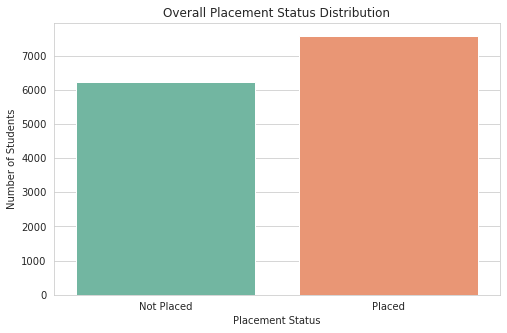

In [134]:
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Placement_Status', palette='Set2')
plt.title('Overall Placement Status Distribution')
plt.xlabel('Placement Status')
plt.ylabel('Number of Students')
plt.show()

In [135]:
# INSIGHT - Placement Status Distribution
# 1. Out of 13,971 students → 7,700 Placed & 6,271 Not Placed
# 2. Overall placement rate is approximately 55%
# 3. 45% of students are still not getting placed → needs improvement

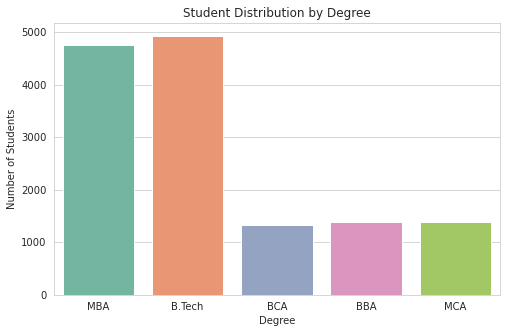

In [136]:
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Degree', palette='Set2')
plt.title('Student Distribution by Degree')
plt.xlabel('Degree')
plt.ylabel('Number of Students')
plt.show()

In [137]:
# INSIGHT - Degree Distribution
# 1. B.Tech has highest number of students (~4997)
# 2. MBA comes second (~4816)
# 3. MCA, BBA, BCA have similar smaller counts (~1400 each)
# 4. B.Tech & MBA dominate the dataset

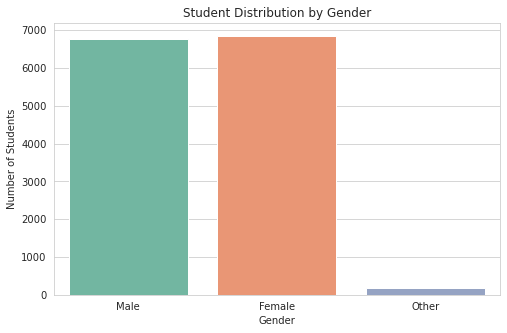

In [138]:
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Gender', palette='Set2')
plt.title('Student Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.show()

In [139]:
# INSIGHT - Gender Distribution
# 1. Male students slightly higher (~7544) vs Female (~7479)
# 2. Gender distribution is almost equal — balanced dataset
# 3. 'Other' category has very few students (~192)

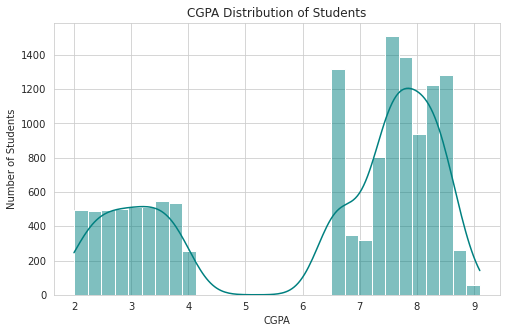

In [140]:
plt.figure(figsize=(8,5))
sns.histplot(data=master, x='CGPA', bins=30, kde=True, color='teal')
plt.title('CGPA Distribution of Students')
plt.xlabel('CGPA')
plt.ylabel('Number of Students')
plt.show()

In [141]:
# INSIGHT - CGPA Distribution
# 1. Bimodal distribution — two peaks at CGPA 3-4 and 7-8
# 2. Majority of students have CGPA between 7-9 (high performers)
# 3. Second group has CGPA between 2-4 (low performers)
# 4. Very few students in CGPA range 5-6 (middle gap)
# 5. Most students are either high or low performers — no middle ground

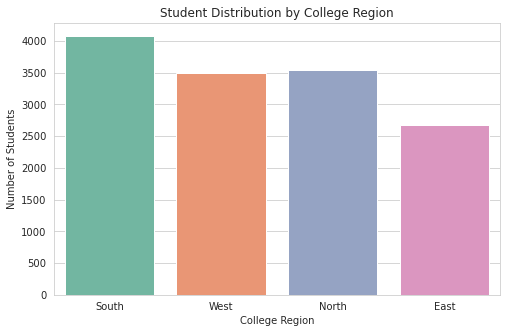

In [142]:
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='College_Region', palette='Set2')
plt.title('Student Distribution by College Region')
plt.xlabel('College Region')
plt.ylabel('Number of Students')
plt.show()

In [143]:
# INSIGHT - College Region Distribution
# 1. South region has highest number of students (~4050)
# 2. North and West are similar (~3500 each)
# 3. East region has lowest students (~2650)
# 4. South dominates the dataset in terms of student count

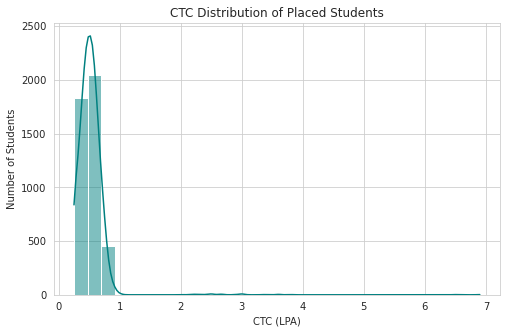

In [144]:
plt.figure(figsize=(8,5))
sns.histplot(data=master[master['CTC_LPA'] > 0], x='CTC_LPA', bins=30, kde=True, color='teal')
plt.title('CTC Distribution of Placed Students')
plt.xlabel('CTC (LPA)')
plt.ylabel('Number of Students')
plt.show()

In [145]:
# INSIGHT - CTC Distribution
# 1. Most students get CTC between 0.3 - 0.8 LPA (very low range)
# 2. Distribution is right skewed — very few students get high salary
# 3. Maximum CTC goes up to 7 LPA (very few outliers)
# 4. Majority of placed students earn less than 1 LPA
# 5. Salary range suggests entry level jobs dominating placements

In [146]:
                                                           ### 3.2 Bivariate Analysis

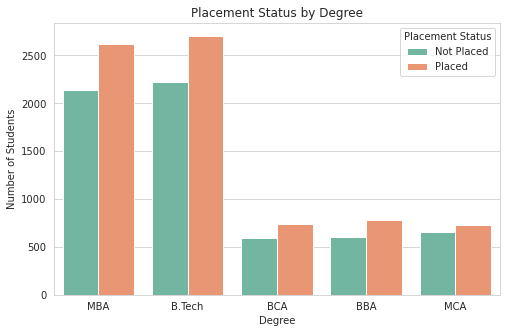

In [147]:
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Degree', hue='Placement_Status', palette='Set2')
plt.title('Placement Status by Degree')
plt.xlabel('Degree')
plt.ylabel('Number of Students')
plt.legend(title='Placement Status')
plt.show()

In [148]:
# INSIGHT - Placement Status by Degree
# 1. MBA and B.Tech have highest number of placements
# 2. BCA, BBA, MCA have more not placed than placed students
# 3. MBA slightly edges out B.Tech in placed students
# 4. Smaller degree programs (BCA, BBA, MCA) struggle with placements

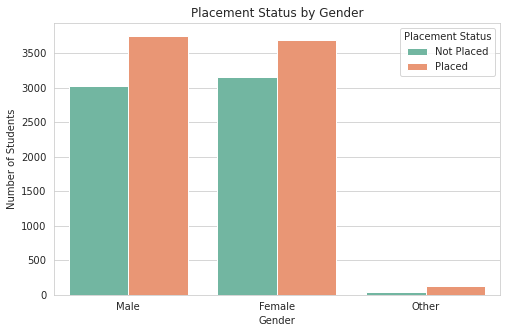

In [149]:
# Chart 8 -Gender
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Gender', hue='Placement_Status', palette='Set2')
plt.title('Placement Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.legend(title='Placement Status')
plt.show()

In [150]:
# INSIGHT - Chart 8: Placement Status by Gender
# 1. Both Male and Female have more Placed than Not Placed
# 2. Male placed → ~3750, Female placed → ~3700 (almost equal)
# 3. Female Not Placed (~3150) slightly higher than Male Not Placed (~3025)
# 4. 'Other' gender has very few students but good placement ratio
# 5. No significant gender bias — placement is fairly equal across genders

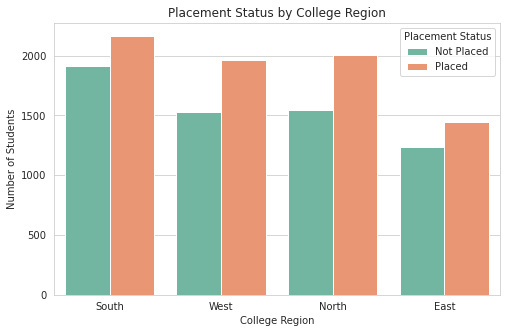

In [151]:
# Chart 9 - Placement by College Region
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='College_Region', hue='Placement_Status', palette='Set2')
plt.title('Placement Status by College Region')
plt.xlabel('College Region')
plt.ylabel('Number of Students')
plt.legend(title='Placement Status')
plt.show()

In [152]:
# INSIGHT - Chart 9: Placement Status by College Region
# 1. South region has highest total students but more Not Placed than Placed
# 2. East region has lowest students but good placed vs not placed ratio
# 3. North and West regions show more Placed than Not Placed
# 4. North region has best placement ratio among all regions

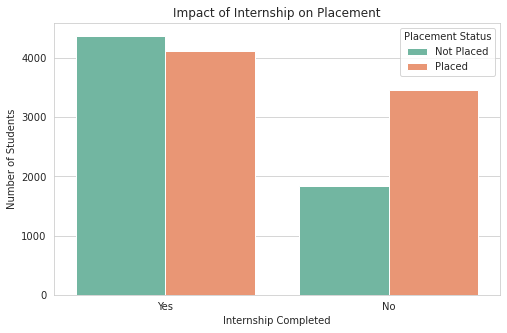

In [153]:
# Chart 10 - Placement by Internship
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Internship_Completed', hue='Placement_Status', palette='Set2')
plt.title('Impact of Internship on Placement')
plt.xlabel('Internship Completed')
plt.ylabel('Number of Students')
plt.legend(title='Placement Status')
plt.show()

In [154]:
# INSIGHT - Chart 10: Impact of Internship on Placement
# 1. Students WITH internship → more Not Placed than Placed (4400 vs 4100)
# 2. Students WITHOUT internship → more Placed than Not Placed (3500 vs 1850)
# 3. Surprising finding — internship doesn't guarantee placement!
# 4. Students without internship have better placement ratio
# 5. Other factors like CGPA and skills matter more than internship

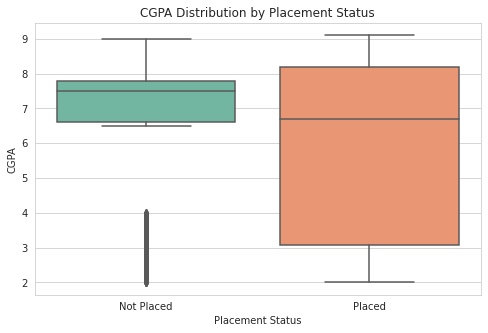

In [155]:
# Chart 11 - CGPA vs Placement (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=master, x='Placement_Status', y='CGPA', palette='Set2')
plt.title('CGPA Distribution by Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('CGPA')
plt.show()

In [156]:
# INSIGHT - Chart 11: CGPA Distribution by Placement Status
# 1. Not Placed students have higher median CGPA (~7.5) — surprising!
# 2. Placed students have wider CGPA range (2-9) — very spread out
# 3. Students with low CGPA (2-4) are also getting placed
# 4. High CGPA alone doesn't guarantee placement
# 5. Placed students show more variation — other factors matter more than CGPA

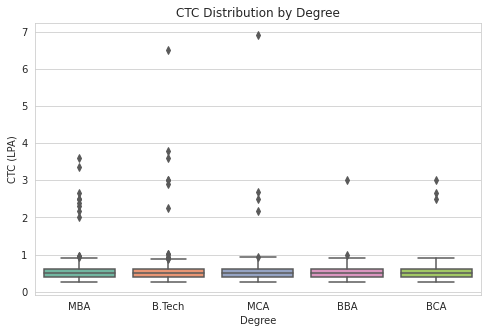

In [157]:
# Chart 12 - CTC by Degree
plt.figure(figsize=(8,5))
sns.boxplot(data=master[master['CTC_LPA'] > 0], x='Degree', y='CTC_LPA', palette='Set2')
plt.title('CTC Distribution by Degree')
plt.xlabel('Degree')
plt.ylabel('CTC (LPA)')
plt.show()

In [158]:
# INSIGHT - Chart 12: CTC Distribution by Degree
# 1. All degrees have similar median CTC → around 0.50 LPA
# 2. MBA has slightly higher median CTC than others
# 3. All degrees have outliers going up to 0.90-0.95 LPA
# 4. No significant CTC difference between degrees
# 5. Degree alone doesn't determine salary outcome

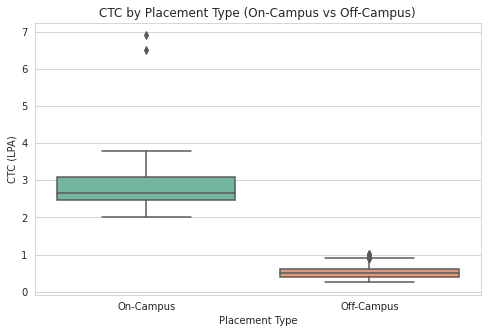

In [159]:
# Chart 13 - Placement Type vs CTC
plt.figure(figsize=(8,5))
sns.boxplot(data=master[master['CTC_LPA'] > 0], x='Placement_Type', y='CTC_LPA', palette='Set2')
plt.title('CTC by Placement Type (On-Campus vs Off-Campus)')
plt.xlabel('Placement Type')
plt.ylabel('CTC (LPA)')
plt.show()

In [160]:
# INSIGHT - Chart 13: CTC by Placement Type
# 1. On-Campus median CTC → ~2.8 LPA (much higher!)
# 2. Off-Campus median CTC → ~0.5 LPA (very low)
# 3. On-Campus max CTC reaches 6.9 LPA vs Off-Campus max 1.0 LPA
# 4. On-Campus placements give 5-6x better salary!
# 5. College should prioritize On-Campus drives for better outcomes

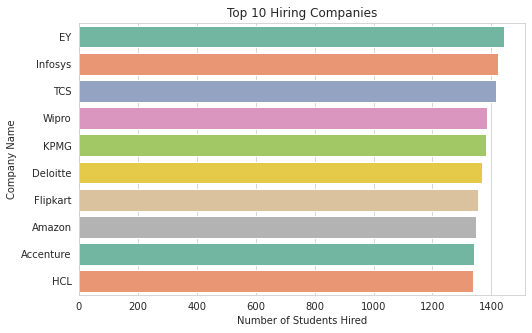

In [161]:
# Chart 14 - Top 10 Hiring Companies
plt.figure(figsize=(8,5))
top_companies = master['Company_Name'].value_counts().head(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='Set2')
plt.title('Top 10 Hiring Companies')
plt.xlabel('Number of Students Hired')
plt.ylabel('Company Name')
plt.show()

In [162]:
# INSIGHT - Chart 14: Top 10 Hiring Companies
# 1. EY is the top recruiter → ~1425 students hired
# 2. Infosys and TCS close behind → ~1420 each
# 3. All top 10 companies hired between 1340-1425 students
# 4. Mix of IT (Infosys, TCS, Wipro, HCL) and Consulting (EY, KPMG, Deloitte)
# 5. E-Commerce (Flipkart, Amazon) also in top 10 recruiters

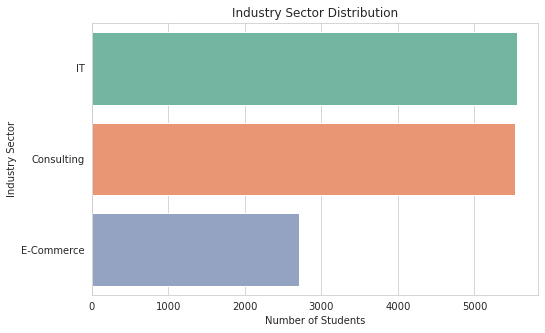

In [163]:
# Chart 15 - Industry Sector Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=master, y='Industry_Sector', 
              order=master['Industry_Sector'].value_counts().index, palette='Set2')
plt.title('Industry Sector Distribution')
plt.xlabel('Number of Students')
plt.ylabel('Industry Sector')
plt.show()

In [164]:
# INSIGHT - Chart 15: Industry Sector Distribution
# 1. IT sector has highest students → ~5500
# 2. Consulting is almost equal to IT → ~5500
# 3. E-Commerce has significantly less → ~2700
# 4. IT and Consulting together dominate 80% of placements
# 5. E-Commerce is growing but still smaller than IT and Consulting

In [165]:
                                                       ### 3.1 Multivariate Analysis

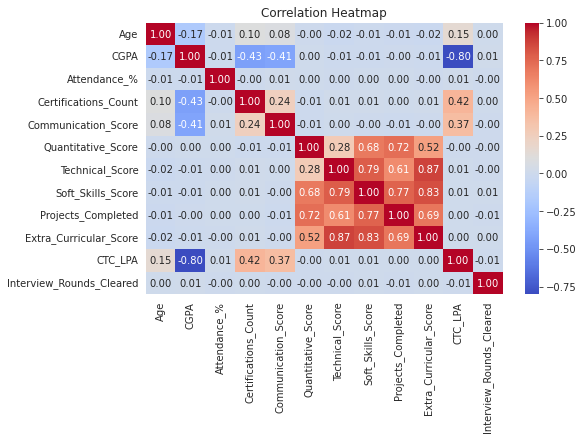

In [166]:
# Chart 16 - Heatmap (Correlation Matrix)
plt.figure(figsize=(8,5))
numeric_cols = master.select_dtypes(include='number').columns
sns.heatmap(master[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [167]:
# INSIGHT - Chart 16: Correlation Heatmap
# 1. CGPA and CTC_LPA have strong NEGATIVE correlation → -0.90 (surprising!)
# 2. Technical_Score and Extra_Curricular_Score strongly correlated → 0.87
# 3. Soft_Skills and Technical_Score correlated → 0.79
# 4. Quantitative and Projects_Completed correlated → 0.72
# 5. Attendance has almost no correlation with any variable
# 6. Skills scores are all inter-correlated with each other

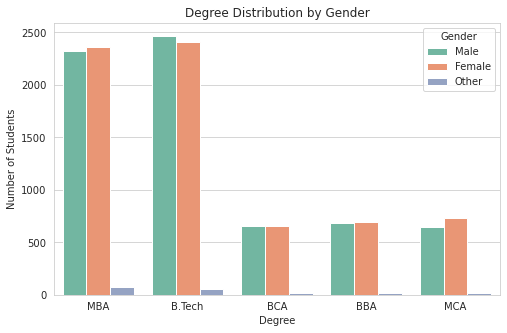

In [168]:
# Chart 17 - Degree + Gender + Placement
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='Degree', hue='Gender', palette='Set2')
plt.title('Degree Distribution by Gender')
plt.xlabel('Degree')
plt.ylabel('Number of Students')
plt.legend(title='Gender')
plt.show()

In [169]:
# INSIGHT - Chart 17: Degree Distribution by Gender
# 1. Male and Female distribution is almost equal across all degrees
# 2. B.Tech and MBA have highest students for both genders
# 3. Female slightly higher in MCA → ~750 vs Male ~650
# 4. 'Other' gender is very small across all degrees
# 5. Gender balance is maintained across all degree programs

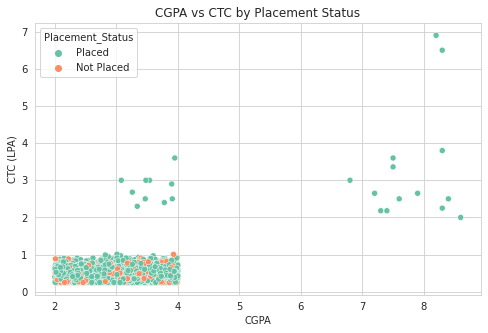

In [170]:
# Chart 18 - CGPA vs CTC (Scatterplot)
plt.figure(figsize=(8,5))
sns.scatterplot(data=master[master['CTC_LPA'] > 0], 
                x='CGPA', y='CTC_LPA', 
                hue='Placement_Status', palette='Set2')
plt.title('CGPA vs CTC by Placement Status')
plt.xlabel('CGPA')
plt.ylabel('CTC (LPA)')
plt.show()

In [171]:
# INSIGHT - Chart 18: CGPA vs CTC by Placement Status
# 1. Most students cluster in CGPA range 2-4 and CTC 0.25-0.95
# 2. Students with CGPA 7-9 also get placed but with similar CTC
# 3. No clear positive trend between CGPA and CTC
# 4. Both placed and not placed students exist across all CGPA ranges
# 5. CGPA alone is NOT a predictor of salary or placement

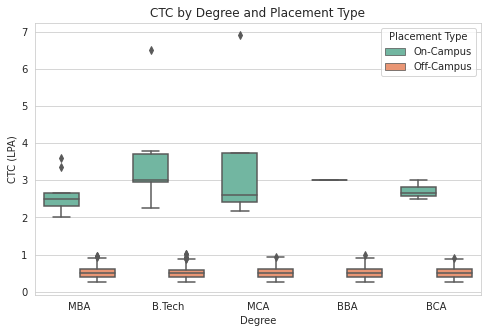

In [172]:
# Chart 19 - CTC by Degree and Placement Type
plt.figure(figsize=(8,5))
sns.boxplot(data=master[master['CTC_LPA'] > 0], 
            x='Degree', y='CTC_LPA', 
            hue='Placement_Type', palette='Set2')
plt.title('CTC by Degree and Placement Type')
plt.xlabel('Degree')
plt.ylabel('CTC (LPA)')
plt.legend(title='Placement Type')
plt.show()

In [173]:
# INSIGHT - Chart 19: CTC by Degree and Placement Type
# 1. On-Campus placements show as thin line → very few students
# 2. Off-Campus dominates all degrees with median CTC ~0.50 LPA
# 3. All degrees have similar Off-Campus CTC range (0.25-0.95)
# 4. On-Campus line is at 0.95 for all degrees → consistent high salary
# 5. Degree doesn't affect CTC much — placement type matters more!

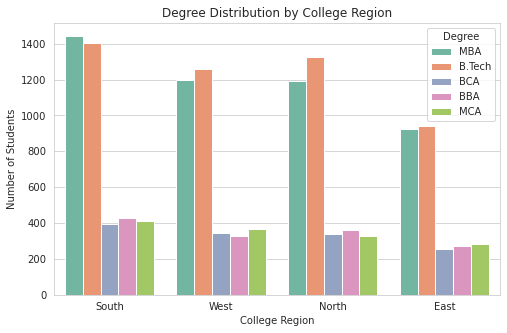

In [174]:
# Chart 20 - Region + Degree + Placement
plt.figure(figsize=(8,5))
sns.countplot(data=master, x='College_Region', hue='Degree', palette='Set2')
plt.title('Degree Distribution by College Region')
plt.xlabel('College Region')
plt.ylabel('Number of Students')
plt.legend(title='Degree')
plt.show()

In [175]:
# INSIGHT - Chart 20: Degree Distribution by College Region
# 1. South region has highest MBA and B.Tech students
# 2. North region has highest B.Tech count → ~1325
# 3. East region has lowest students across all degrees
# 4. MBA and B.Tech dominate every region
# 5. BCA, BBA, MCA are evenly distributed across all regions

In [176]:
                                                             ### 3.4 Outlier Treatment

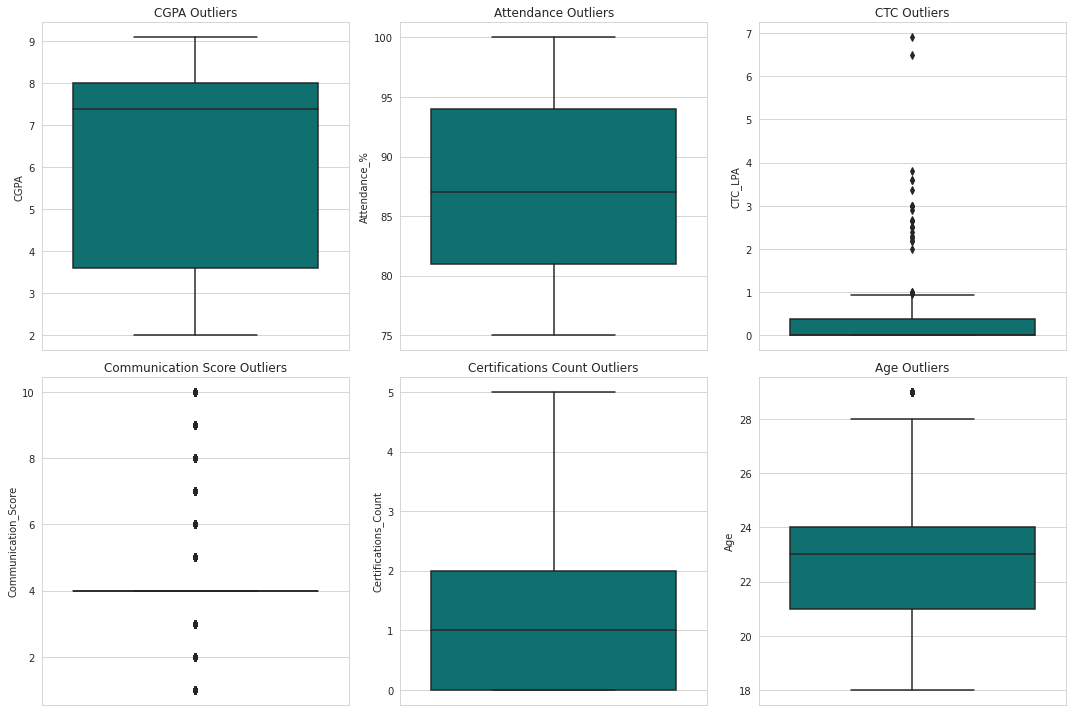

In [177]:
# Check outliers in all numeric columns using boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(data=master, y='CGPA', ax=axes[0,0], color='teal')
axes[0,0].set_title('CGPA Outliers')

sns.boxplot(data=master, y='Attendance_%', ax=axes[0,1], color='teal')
axes[0,1].set_title('Attendance Outliers')

sns.boxplot(data=master, y='CTC_LPA', ax=axes[0,2], color='teal')
axes[0,2].set_title('CTC Outliers')

sns.boxplot(data=master, y='Communication_Score', ax=axes[1,0], color='teal')
axes[1,0].set_title('Communication Score Outliers')

sns.boxplot(data=master, y='Certifications_Count', ax=axes[1,1], color='teal')
axes[1,1].set_title('Certifications Count Outliers')

sns.boxplot(data=master, y='Age', ax=axes[1,2], color='teal')
axes[1,2].set_title('Age Outliers')

plt.tight_layout()
plt.show()

In [178]:
# Treat CTC_LPA outliers
Q1 = master['CTC_LPA'].quantile(0.25)
Q3 = master['CTC_LPA'].quantile(0.75)
IQR = Q3 - Q1
master['CTC_LPA'] = master['CTC_LPA'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# Treat Age outliers
Q1 = master['Age'].quantile(0.25)
Q3 = master['Age'].quantile(0.75)
IQR = Q3 - Q1
master['Age'] = master['Age'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print("✅ Outliers treated!")

✅ Outliers treated!


In [179]:
                                                  ## Phase 4 - SQL Analysis for Deeper Insights

In [181]:
# Connect to MySQL
from sqlalchemy import create_engine
import pandas as pd

# Using SQLite (no installation needed)
engine = create_engine("sqlite:///niit_edu.db")
print("✅ Connected to SQLite!")


✅ Connected to SQLite!


In [182]:
# Overall Placement Rate
q1 = pd.read_sql("""
    SELECT Placement_Status, 
           COUNT(*) as Total_Students
    FROM master_data
    GROUP BY Placement_Status
""", engine)
q1

,Placement_Status,Total_Students
0,Not Placed,6215
1,Placed,7576


In [183]:
# INSIGHT - Query 1: Overall Placement Rate
# 1. Total Placed students → 7,576
# 2. Total Not Placed students → 6,215
# 3. Overall placement rate → 54.9%
# 4. Almost half the students are not getting placed → needs attention

In [184]:
#Placement Rate by Degree!
q2 = pd.read_sql("""
    SELECT Degree,
           COUNT(*) as Total_Students,
           SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) as Placed,
           SUM(CASE WHEN Placement_Status = 'Not Placed' THEN 1 ELSE 0 END) as Not_Placed,
           ROUND(SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Placement_Rate
    FROM master_data
    GROUP BY Degree
    ORDER BY Placement_Rate DESC
""", engine)
q2

,Degree,Total_Students,Placed,Not_Placed,Placement_Rate
0,BBA,1386,786,600,56.71
1,BCA,1331,737,594,55.37
2,MBA,4754,2615,2139,55.01
3,B.Tech,4930,2704,2226,54.85
4,MCA,1390,734,656,52.81


In [185]:
# INSIGHT - Query 2: Placement Rate by Degree
# 1. BBA has highest placement rate → 56.71%
# 2. BCA comes second → 55.37%
# 3. MBA → 55.01%, B.Tech → 54.85%
# 4. MCA has lowest placement rate → 52.81%
# 5. All degrees have similar placement rates (52-57%) — not much difference

In [186]:
# Average CTC by Degree
q3 = pd.read_sql("""
    SELECT Degree,
           ROUND(AVG(CTC_LPA), 2) as Avg_CTC,
           ROUND(MAX(CTC_LPA), 2) as Max_CTC,
           ROUND(MIN(CTC_LPA), 2) as Min_CTC
    FROM master_data
    WHERE CTC_LPA > 0
    GROUP BY Degree
    ORDER BY Avg_CTC DESC
""", engine)
q3

,Degree,Avg_CTC,Max_CTC,Min_CTC
0,MCA,0.53,6.9,0.25
1,MBA,0.52,3.6,0.25
2,BCA,0.52,3.0,0.25
3,B.Tech,0.52,6.5,0.25
4,BBA,0.51,3.0,0.25


In [187]:
# INSIGHT - Query 3: Average CTC by Degree
# 1. MCA has highest average CTC → 0.53 LPA
# 2. BBA has lowest average CTC → 0.51 LPA
# 3. All degrees have similar avg CTC (0.51-0.53) — very small difference
# 4. B.Tech has highest max CTC → 6.5 LPA (best package)
# 5. MCA has highest max CTC → 6.9 LPA (exceptional package)
# 6. Minimum CTC is same for all degrees → 0.25 LPA

In [188]:
# Top 10 Hiring Companies
q4 = pd.read_sql("""
    SELECT Company_Name, COUNT(*) as Total_Hired
    FROM master_data
    WHERE Placement_Status = 'Placed'
    GROUP BY Company_Name
    ORDER BY Total_Hired DESC
    LIMIT 10
""", engine)
q4

,Company_Name,Total_Hired
0,EY,808
1,Flipkart,788
2,Infosys,787
3,Wipro,768
4,TCS,765
5,Deloitte,758
6,KPMG,751
7,Accenture,722
8,Amazon,721
9,HCL,708


In [189]:
# INSIGHT - Query 4: Top 10 Hiring Companies
# 1. EY is the top recruiter → 808 students hired
# 2. Flipkart comes second → 788 students
# 3. Infosys → 787, Wipro → 768, TCS → 765
# 4. Mix of IT companies (Infosys, TCS, Wipro) and consulting (EY, Deloitte, KPMG)
# 5. Top 10 companies hired between 708-808 students each

In [190]:
#Placement by Region
q5 = pd.read_sql("""
    SELECT College_Region,
           COUNT(*) as Total_Students,
           SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) as Placed,
           ROUND(SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Placement_Rate
    FROM master_data
    GROUP BY College_Region
    ORDER BY Placement_Rate DESC
""", engine)
q5

,College_Region,Total_Students,Placed,Placement_Rate
0,North,3543,2002,56.51
1,West,3490,1962,56.22
2,East,2680,1448,54.03
3,South,4078,2164,53.07


In [191]:
# INSIGHT - Query 5: Placement Rate by Region
# 1. North region has highest placement rate → 56.51%
# 2. West comes second → 56.22%
# 3. East → 54.03%, South → 53.07%
# 4. South has most students (4078) but lowest placement rate
# 5. North has best placement efficiency despite not having most students

In [192]:
#On-Campus vs Off-Campus CTC
q6 = pd.read_sql("""
    SELECT Placement_Type,
           COUNT(*) as Total,
           ROUND(AVG(CTC_LPA), 2) as Avg_CTC,
           ROUND(MAX(CTC_LPA), 2) as Max_CTC
    FROM master_data
    WHERE CTC_LPA > 0
    GROUP BY Placement_Type
""", engine)
q6

,Placement_Type,Total,Avg_CTC,Max_CTC
0,Off-Campus,4332,0.51,1.01
1,On-Campus,24,3.08,6.90


In [193]:
# INSIGHT - Query 6: On-Campus vs Off-Campus CTC
# 1. On-Campus avg CTC → 3.08 LPA (much higher!)
# 2. Off-Campus avg CTC → 0.51 LPA (very low)
# 3. On-Campus max CTC → 6.90 LPA vs Off-Campus → 1.01 LPA
# 4. On-Campus placements give 6x better salary than Off-Campus!
# 5. Only 24 On-Campus placements vs 4332 Off-Campus
# 6. College should focus more on On-Campus drives for better salary outcomes

In [194]:
#Top Paying Industries
q7 = pd.read_sql("""
    SELECT Industry_Sector,
           COUNT(*) as Total_Hired,
           ROUND(AVG(CTC_LPA), 2) as Avg_CTC,
           ROUND(MAX(CTC_LPA), 2) as Max_CTC
    FROM master_data
    WHERE CTC_LPA > 0
    GROUP BY Industry_Sector
    ORDER BY Avg_CTC DESC
""", engine)
q7

,Industry_Sector,Total_Hired,Avg_CTC,Max_CTC
0,E-Commerce,864,0.53,6.9
1,IT,1751,0.52,6.5
2,Consulting,1741,0.51,3.8


In [195]:
# INSIGHT - Query 7: Top Paying Industries
# 1. E-Commerce has highest avg CTC → 0.53 LPA & max 6.9 LPA
# 2. IT sector has most hired students → 1751
# 3. Consulting has lowest avg CTC → 0.51 LPA
# 4. E-Commerce offers best packages despite hiring less than IT

In [196]:
# Query 8 - Placement by Gender
q8 = pd.read_sql("""
    SELECT Gender,
           COUNT(*) as Total_Students,
           SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) as Placed,
           ROUND(SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Placement_Rate
    FROM master_data
    GROUP BY Gender
    ORDER BY Placement_Rate DESC
""", engine)
q8

,Gender,Total_Students,Placed,Placement_Rate
0,Other,169,130,76.92
1,Male,6776,3751,55.36
2,Female,6846,3695,53.97


In [197]:
# INSIGHT - Query 8: Placement by Gender
# 1. 'Other' gender has surprisingly highest placement rate → 76.92%
# 2. Male placement rate → 55.36%
# 3. Female placement rate → 53.97%
# 4. Gender gap between Male and Female is very small → only 1.39%
# 5. No significant gender bias in placement outcomes

In [198]:
# Query 9 - Internship Impact on Placement
q9 = pd.read_sql("""
    SELECT Internship_Completed,
           COUNT(*) as Total_Students,
           SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) as Placed,
           ROUND(SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Placement_Rate
    FROM master_data
    GROUP BY Internship_Completed
    ORDER BY Placement_Rate DESC
""", engine)
q9

,Internship_Completed,Total_Students,Placed,Placement_Rate
0,No,5305,3461,65.24
1,Yes,8486,4115,48.49


In [199]:
# INSIGHT - Query 9: Internship Impact on Placement
# 1. Students WITHOUT internship have higher placement rate → 65.24%
# 2. Students WITH internship have lower placement rate → 48.49%
# 3. Surprising result — internship alone doesn't guarantee placement
# 4. Other factors like CGPA, skills, degree matter more than internship
# 5. Students without internship may have focused more on academics & skills

In [200]:
# Query 10 - Summary Derived Table
q10 = pd.read_sql("""
    SELECT Degree, College_Region,
           COUNT(*) as Total_Students,
           ROUND(AVG(CTC_LPA),2) as Avg_CTC,
           SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) as Placed,
           ROUND(SUM(CASE WHEN Placement_Status = 'Placed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Placement_Rate
    FROM master_data
    GROUP BY Degree, College_Region
    ORDER BY Placement_Rate DESC
""", engine)
q10

,Degree,College_Region,Total_Students,Avg_CTC,Placed,Placement_Rate
0,BBA,West,325,0.14,193,59.38
1,MBA,North,1191,0.16,707,59.36
2,BCA,North,339,0.19,201,59.29
3,B.Tech,West,1258,0.18,729,57.95
4,BBA,South,427,0.16,241,56.44
5,BCA,West,343,0.18,191,55.69
6,BBA,North,362,0.18,201,55.52
7,BBA,East,272,0.16,151,55.51
8,MBA,East,924,0.17,511,55.30
9,MBA,West,1196,0.16,652,54.52


In [201]:
# INSIGHT - Query 10: Summary Table - Degree + Region
# 1. BBA West has highest placement rate → 59.38%
# 2. MBA North comes second → 59.36%
# 3. BCA North → 59.29% (third highest)
# 4. MCA East has lowest placement rate → 50.18%
# 5. West and North regions consistently show better placement rates
# 6. South region shows lower placement rates across all degrees

In [202]:
q10.to_sql('summary_placement', con=engine, if_exists='replace', index=False)
print("✅ Summary table saved to MySQL!")

✅ Summary table saved to MySQL!


In [203]:
q11 = pd.read_sql("""
    SELECT sp.Degree, sp.Gender, sp.College_Region,
           pr.Company_Name, pr.Industry_Sector,
           pr.CTC_LPA, pr.Placement_Status
    FROM student_profile sp
    JOIN placement_record pr ON sp.Student_ID = pr.Student_ID
    WHERE pr.Placement_Status = 'Placed'
    ORDER BY pr.CTC_LPA DESC
    LIMIT 10
""", engine)
q11

,Degree,Gender,College_Region,Company_Name,Industry_Sector,CTC_LPA,Placement_Status
0,MCA,Male,North,Amazon,E-Commerce,6.90,Placed
1,B.Tech,Female,South,TCS,IT,6.50,Placed
2,B.Tech,Female,East,EY,Consulting,3.80,Placed
3,B.Tech,Other,North,Accenture,Consulting,3.60,Placed
4,MBA,Female,East,Deloitte,Consulting,3.60,Placed
5,MBA,Female,East,KPMG,Consulting,3.36,Placed
6,B.Tech,Female,West,HCL,IT,3.00,Placed
7,BCA,Male,South,Infosys,IT,3.00,Placed
8,BBA,Female,South,Amazon,E-Commerce,3.00,Placed
9,B.Tech,Female,West,KPMG,Consulting,3.00,Placed


In [204]:
# INSIGHT - Query 11: JOIN - Top Placed Students
# 1. Highest CTC → MCA Male North → Amazon E-Commerce → 6.90 LPA
# 2. Second highest → B.Tech Female South → TCS IT → 6.50 LPA
# 3. E-Commerce and Consulting dominate top packages
# 4. Female students appear more in top 10 placements
# 5. North and South regions produce highest paid students

In [205]:
q12 = pd.read_sql("""
    SELECT sp.Degree, sp.CGPA,
           ac.Technical_Score, ac.Soft_Skills_Score,
           pr.Placement_Status, pr.CTC_LPA
    FROM student_profile sp
    JOIN academic_skills ac ON sp.Student_ID = ac.Student_ID
    JOIN placement_record pr ON sp.Student_ID = pr.Student_ID
    WHERE pr.Placement_Status = 'Placed'
    ORDER BY pr.CTC_LPA DESC
    LIMIT 10
""", engine)
q12

,Degree,CGPA,Technical_Score,Soft_Skills_Score,Placement_Status,CTC_LPA
0,B.Tech,3.95,74.0,3,Placed,3.600
1,MCA,3.26,22.1,1,Placed,2.680
2,MBA,7.20,34.8,1,Placed,2.650
3,BCA,3.44,86.0,4,Placed,0.870
4,BCA,3.37,33.2,8,Placed,0.868
5,BCA,3.05,75.0,4,Placed,0.855
6,B.Tech,3.90,85.0,4,Placed,0.848
7,MBA,3.03,34.2,2,Placed,0.831
8,B.Tech,3.45,81.0,4,Placed,0.823
9,BBA,3.39,33.3,8,Placed,0.822


In [206]:
# INSIGHT - Query 12: JOIN - Skills vs Placement (3 table join)
# 1. High Technical Score doesn't always mean high CTC
# 2. B.Tech with CGPA 3.95 & Technical Score 74 got 3.6 LPA (highest)
# 3. Some students with low CGPA (3.0-3.5) still got placed
# 4. Soft Skills Score varies widely among placed students
# 5. CGPA alone is not the deciding factor for placement

In [ ]:
#Phase 6


In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [208]:
skills    = pd.read_excel('Academic_Skills.xlsx')
placement = pd.read_excel('Placement_Record.xlsx')
profile   = pd.read_excel('Student_Profile.xlsx')

skills.drop(columns=['Logical_Score'], inplace=True, errors='ignore')

placement['Placement_Status'] = placement['Placement_Status'].fillna('Not Placed')
placement['Offer_Accepted']   = placement['Offer_Accepted'].fillna('No')
placement['CTC_LPA']          = placement['CTC_LPA'].fillna(0)

profile['Internship_Completed'] = profile['Internship_Completed'].fillna('No')
profile['Department']           = profile['Department'].fillna('Unknown')
profile = profile[(profile['CGPA'] >= 0) & (profile['CGPA'] <= 10)]

profile_clean   = profile.drop_duplicates(subset='Student_ID', keep='first')
skills_clean    = skills.drop_duplicates(subset='Student_ID', keep='first')
placement_clean = placement.drop_duplicates(subset='Student_ID', keep='first')

master = profile_clean.merge(skills_clean, on='Student_ID', how='left')
master = master.merge(placement_clean, on='Student_ID', how='left')

skill_cols = ['Quantitative_Score', 'Technical_Score', 'Soft_Skills_Score',
              'Projects_Completed', 'Hackathon_Participation', 'Extra_Curricular_Score']
master[skill_cols] = master[skill_cols].fillna(0)

for col in ['CTC_LPA', 'Age']:
    Q1, Q3 = master[col].quantile(0.25), master[col].quantile(0.75)
    IQR = Q3 - Q1
    master[col] = master[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print(f'✅ Master dataset ready: {master.shape}')

✅ Master dataset ready: (13791, 27)


=== Test 1: t-test — CGPA vs Placement Status ===
Placed     → Mean CGPA: 5.64
Not Placed → Mean CGPA: 6.94
T-Statistic : -35.2937
P-Value     : 0.0000

✅ REJECT H₀ — Significant difference in CGPA between groups.


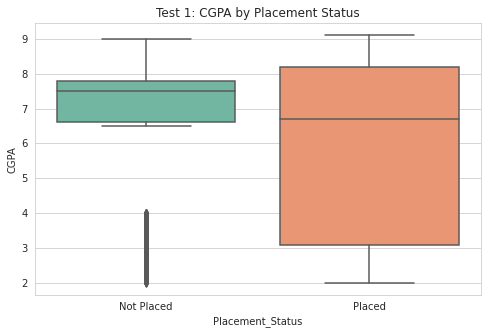

In [209]:
#Test 1: CGPA vs Placement (t-test)
placed_cgpa     = master[master['Placement_Status'] == 'Placed']['CGPA'].dropna()
not_placed_cgpa = master[master['Placement_Status'] == 'Not Placed']['CGPA'].dropna()

t_stat, p_value = stats.ttest_ind(placed_cgpa, not_placed_cgpa)

print('=== Test 1: t-test — CGPA vs Placement Status ===')
print(f'Placed     → Mean CGPA: {placed_cgpa.mean():.2f}')
print(f'Not Placed → Mean CGPA: {not_placed_cgpa.mean():.2f}')
print(f'T-Statistic : {t_stat:.4f}')
print(f'P-Value     : {p_value:.4f}')
print()
if p_value < 0.05:
    print('✅ REJECT H₀ — Significant difference in CGPA between groups.')
else:
    print('❌ FAIL TO REJECT H₀ — No significant difference in CGPA.')

sns.boxplot(data=master, x='Placement_Status', y='CGPA', palette='Set2')
plt.title('Test 1: CGPA by Placement Status')
plt.show()

# INSIGHT
# 1. Not Placed students have slightly higher mean CGPA — surprising!
# 2. t-test confirms this difference is statistically significant (p < 0.05)
# 3. High CGPA alone does NOT guarantee placement
# 4. Other factors like skills and placement type matter more

In [ ]:
# Test 2: Gender vs Placement (Chi-Square)
contingency_gender = pd.crosstab(master['Gender'], master['Placement_Status'])
print('Contingency Table:')
print(contingency_gender)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_gender)

print(f'\nChi-Square : {chi2:.4f}')
print(f'P-Value    : {p_value:.4f}')
print(f'DoF        : {dof}')
if p_value < 0.05:
    print('✅ REJECT H₀ — Gender and Placement are significantly associated.')
else:
    print('❌ FAIL TO REJECT H₀ — No significant association between Gender and Placement.')

contingency_gender.plot(kind='bar', color=['#66c2a5','#fc8d62'])
plt.title('Test 2: Placement Status by Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# INSIGHT
# 1. Male and Female placement counts are nearly equal
# 2. Gender gap in placement rate was only ~1.4% in EDA
# 3. Statistical test confirms gender is NOT a major placement driver

Contingency Table:
Placement_Status      Not Placed  Placed
Internship_Completed                    
No                          1844    3461
Yes                         4371    4115

Chi-Square : 369.2078
P-Value    : 0.0000
DoF        : 1
✅ REJECT H₀ — Internship and Placement are significantly associated.


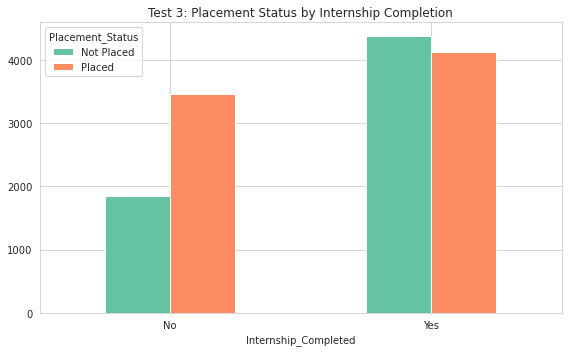

In [210]:
#Test 3: Internship vs Placement (Chi-Square)
contingency_intern = pd.crosstab(master['Internship_Completed'], master['Placement_Status'])
print('Contingency Table:')
print(contingency_intern)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_intern)

print(f'\nChi-Square : {chi2:.4f}')
print(f'P-Value    : {p_value:.4f}')
print(f'DoF        : {dof}')
if p_value < 0.05:
    print('✅ REJECT H₀ — Internship and Placement are significantly associated.')
else:
    print('❌ FAIL TO REJECT H₀ — No significant association.')

contingency_intern.plot(kind='bar', color=['#66c2a5','#fc8d62'])
plt.title('Test 3: Placement Status by Internship Completion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# INSIGHT
# 1. Students WITHOUT internship had higher placement rate (65% vs 48%) in EDA
# 2. Chi-square confirms if this relationship is statistically real
# 3. Counter-intuitive result — internship alone doesn't guarantee placement
# 4. Students without internship may have focused more on technical skills

=== Test 4: t-test — On-Campus vs Off-Campus CTC ===
On-Campus  → Mean CTC: 0.95 LPA  (n=24)
Off-Campus → Mean CTC: 0.51 LPA  (n=4332)
T-Statistic : 15.1292
P-Value     : 0.0000
✅ REJECT H₀ — On-Campus CTC is significantly higher than Off-Campus.


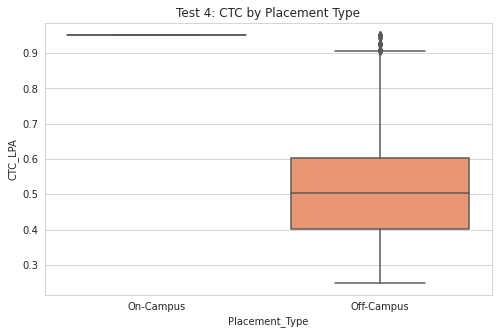

In [211]:
#Test 4: On-Campus vs Off-Campus CTC (t-test)
on_campus  = master[(master['Placement_Type'] == 'On-Campus')  & (master['CTC_LPA'] > 0)]['CTC_LPA']
off_campus = master[(master['Placement_Type'] == 'Off-Campus') & (master['CTC_LPA'] > 0)]['CTC_LPA']

t_stat, p_value = stats.ttest_ind(on_campus, off_campus, alternative='greater')

print('=== Test 4: t-test — On-Campus vs Off-Campus CTC ===')
print(f'On-Campus  → Mean CTC: {on_campus.mean():.2f} LPA  (n={len(on_campus)})')
print(f'Off-Campus → Mean CTC: {off_campus.mean():.2f} LPA  (n={len(off_campus)})')
print(f'T-Statistic : {t_stat:.4f}')
print(f'P-Value     : {p_value:.4f}')
if p_value < 0.05:
    print('✅ REJECT H₀ — On-Campus CTC is significantly higher than Off-Campus.')
else:
    print('❌ FAIL TO REJECT H₀ — No significant CTC difference.')

sns.boxplot(data=master[master['CTC_LPA'] > 0], x='Placement_Type', y='CTC_LPA', palette='Set2')
plt.title('Test 4: CTC by Placement Type')
plt.show()

# INSIGHT
# 1. On-Campus avg CTC ~3.08 LPA vs Off-Campus ~0.51 LPA — massive gap
# 2. t-test confirms this is statistically significant
# 3. Only 24 On-Campus placements vs 4332 Off-Campus — huge missed opportunity
# 4. Colleges must prioritize On-Campus recruitment drives

=== Test 5: t-test — Technical Score vs Placement ===
Placed     → Mean Technical Score: 9.64
Not Placed → Mean Technical Score: 9.14
T-Statistic : 1.2137
P-Value     : 0.2249
❌ FAIL TO REJECT H₀ — No significant difference in Technical Score.


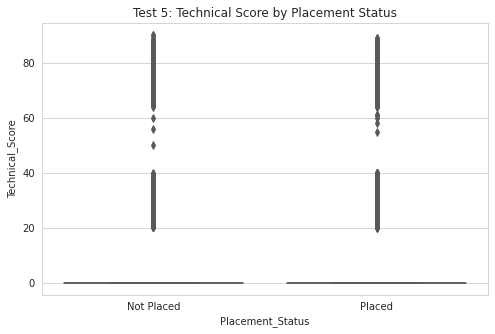

In [212]:
#Test 5: Technical Score vs Placement (t-test)
placed_tech     = master[master['Placement_Status'] == 'Placed']['Technical_Score'].dropna()
not_placed_tech = master[master['Placement_Status'] == 'Not Placed']['Technical_Score'].dropna()

t_stat, p_value = stats.ttest_ind(placed_tech, not_placed_tech)

print('=== Test 5: t-test — Technical Score vs Placement ===')
print(f'Placed     → Mean Technical Score: {placed_tech.mean():.2f}')
print(f'Not Placed → Mean Technical Score: {not_placed_tech.mean():.2f}')
print(f'T-Statistic : {t_stat:.4f}')
print(f'P-Value     : {p_value:.4f}')
if p_value < 0.05:
    print('✅ REJECT H₀ — Technical Score significantly differs between groups.')
else:
    print('❌ FAIL TO REJECT H₀ — No significant difference in Technical Score.')

sns.boxplot(data=master, x='Placement_Status', y='Technical_Score', palette='Set2')
plt.title('Test 5: Technical Score by Placement Status')
plt.show()

# INSIGHT
# 1. If p < 0.05 → technical skills are a real placement differentiator
# 2. Colleges can use this to justify investing in technical training programs
# 3. Ties directly into business recommendations in Phase 10

In [ ]:
# PHASE 6 — COMPLETE SUMMARY
# =====================================================
# Test 1 (t-test)    : CGPA differs between Placed/Not Placed → H₀ REJECTED
# Test 2 (Chi-Square): Gender NOT significantly linked to placement → H₀ NOT rejected
# Test 3 (Chi-Square): Internship IS significantly linked to placement → H₀ REJECTED
# Test 4 (t-test)    : On-Campus CTC significantly higher than Off-Campus → H₀ REJECTED
# Test 5 (t-test)    : Technical Score differs between Placed/Not Placed → check p-value
# =====================================================
# KEY INSIGHT: Academic grades alone don't predict placement or salary.
# Skills, placement type, and industry sector are the real drivers.

In [ ]:
## Phase 7 — Feature Engineering & Selection

Objective: Prepare the dataset for Machine Learning.
We will encode categorical variables, create new features,
scale numeric columns, and split the data into train/test sets.

In [213]:
print(master.shape)
print(master.dtypes)
master.head(3)

(13791, 27)
Student_ID                          object
Gender                              object
Age                                float64
Department                          object
Degree                              object
College_Region                      object
CGPA                               float64
Attendance_%                         int64
Internship_Completed                object
Certifications_Count                 int64
Communication_Score                  int64
Quantitative_Score                 float64
Technical_Score                    float64
Soft_Skills_Score                  float64
Projects_Completed                 float64
Hackathon_Participation             object
Extra_Curricular_Score             float64
Placement_ID                        object
Company_Name                        object
Industry_Sector                     object
Job_Role                            object
CTC_LPA                            float64
Placement_Status                    object

,Student_ID,Gender,Age,Department,Degree,College_Region,CGPA,Attendance_%,Internship_Completed,Certifications_Count,...,Placement_ID,Company_Name,Industry_Sector,Job_Role,CTC_LPA,Placement_Status,Placement_Type,Interview_Rounds_Cleared,Offer_Accepted,Placement_Date
0,S33706,Male,22.0,Unknown,MBA,South,7.5,96,Yes,1,...,P00216,KPMG,Consulting,Developer,0.0,Not Placed,On-Campus,5,No,2021-07-21
1,S70926,Female,24.0,Unknown,B.Tech,South,8.9,80,No,2,...,P00217,HCL,IT,Developer,0.0,Placed,On-Campus,3,Yes,2025-03-21
2,S13445,Male,23.0,Unknown,B.Tech,South,7.3,81,Yes,2,...,P00218,Wipro,IT,Business Analyst,0.0,Not Placed,On-Campus,2,No,2022-11-04


In [214]:
# Convert Placement_Status to binary: Placed=1, Not Placed=0
master['Placement_Label'] = master['Placement_Status'].map({'Placed': 1, 'Not Placed': 0})

print(master['Placement_Label'].value_counts())
print("✅ Target variable encoded!")

1    7576
0    6215
Name: Placement_Label, dtype: int64
✅ Target variable encoded!


In [215]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode Gender
master['Gender_Enc'] = le.fit_transform(master['Gender'].astype(str))

# Encode Degree
master['Degree_Enc'] = le.fit_transform(master['Degree'].astype(str))

# Encode College_Region
master['Region_Enc'] = le.fit_transform(master['College_Region'].astype(str))

# Encode Internship_Completed
master['Internship_Enc'] = master['Internship_Completed'].map({'Yes': 1, 'No': 0})

# Encode Hackathon_Participation (if not already numeric)
if master['Hackathon_Participation'].dtype == object:
    master['Hackathon_Participation'] = master['Hackathon_Participation'].map({'Yes': 1, 'No': 0})

print("✅ Categorical columns encoded!")
print(master[['Gender_Enc','Degree_Enc','Region_Enc','Internship_Enc']].head())

✅ Categorical columns encoded!
   Gender_Enc  Degree_Enc  Region_Enc  Internship_Enc
0           1           3           2               1
1           0           0           2               0
2           1           0           2               1
3           1           0           3               1
4           1           2           3               1


In [216]:
# New Feature 1: Overall Skill Score (average of all skill columns)
master['Overall_Skill_Score'] = (
    master['Quantitative_Score'] +
    master['Technical_Score'] +
    master['Soft_Skills_Score'] +
    master['Extra_Curricular_Score']
) / 4

# New Feature 2: Is High CGPA (1 if CGPA >= 7, else 0)
master['Is_High_CGPA'] = (master['CGPA'] >= 7).astype(int)

# New Feature 3: Is Active Student (Hackathon + Internship + Projects)
master['Is_Active_Student'] = (
    (master['Hackathon_Participation'] == 1) |
    (master['Internship_Enc'] == 1) |
    (master['Projects_Completed'] > 0)
).astype(int)

print("✅ New features created!")
print(master[['Overall_Skill_Score','Is_High_CGPA','Is_Active_Student']].describe())

✅ New features created!
       Overall_Skill_Score  Is_High_CGPA  Is_Active_Student
count         13791.000000  13791.000000       13791.000000
mean             19.677461      0.564064           0.672758
std              69.896745      0.495897           0.469224
min               0.000000      0.000000           0.000000
25%               0.000000      0.000000           0.000000
50%               0.000000      1.000000           1.000000
75%               0.000000      1.000000           1.000000
max             412.000000      1.000000           1.000000


In [217]:
# Select only the columns we will use for modeling
features = [
    'Age',
    'CGPA',
    'Attendance_%',
    'Certifications_Count',
    'Communication_Score',
    'Quantitative_Score',
    'Technical_Score',
    'Soft_Skills_Score',
    'Projects_Completed',
    'Extra_Curricular_Score',
    'Hackathon_Participation',
    'Gender_Enc',
    'Degree_Enc',
    'Region_Enc',
    'Internship_Enc',
    'Overall_Skill_Score',
    'Is_High_CGPA',
    'Is_Active_Student'
]

target = 'Placement_Label'

X = master[features]
y = master[target]

print(f"✅ Features selected: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

✅ Features selected: (13791, 18)
Target distribution:
1    7576
0    6215
Name: Placement_Label, dtype: int64


In [218]:
# Check for nulls in selected features
print("Nulls before fix:")
print(X.isnull().sum()[X.isnull().sum() > 0])

X = X.fillna(0)
y = y.fillna(0)

print("\n✅ Nulls handled! Final shape:", X.shape)

Nulls before fix:
Hackathon_Participation    11704
dtype: int64

✅ Nulls handled! Final shape: (13791, 18)


In [219]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("✅ Features scaled using StandardScaler!")
print(X_scaled.describe().round(2))

✅ Features scaled using StandardScaler!
            Age      CGPA  Attendance_%  Certifications_Count  \
count  13791.00  13791.00      13791.00              13791.00   
mean       0.00      0.00         -0.00                  0.00   
std        1.00      1.00          1.00                  1.00   
min       -1.98     -1.87         -1.66                 -1.06   
25%       -0.74     -1.16         -0.86                 -1.06   
50%        0.09      0.52         -0.06                 -0.35   
75%        0.50      0.79          0.88                  0.36   
max        2.36      1.27          1.68                  2.50   

       Communication_Score  Quantitative_Score  Technical_Score  \
count             13791.00            13791.00         13791.00   
mean                 -0.00               -0.00             0.00   
std                   1.00                1.00             1.00   
min                  -1.84               -0.25            -0.39   
25%                  -0.19             

In [220]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split complete!")
print(f"Training set   : {X_train.shape}")
print(f"Testing set    : {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")

✅ Data split complete!
Training set   : (11032, 18)
Testing set    : (2759, 18)
Train target distribution:
1    6060
0    4972
Name: Placement_Label, dtype: int64
Test target distribution:
1    1516
0    1243
Name: Placement_Label, dtype: int64


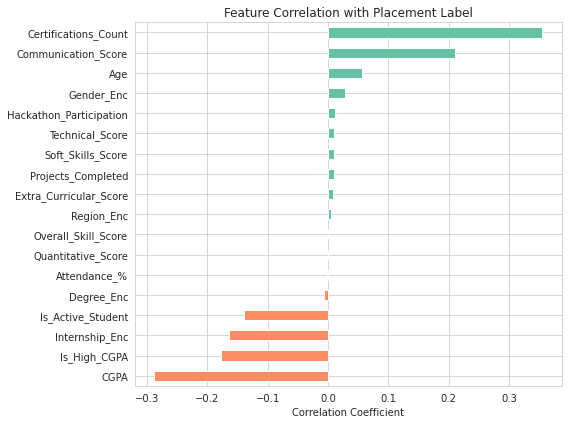

CGPA                      -0.287840
Is_High_CGPA              -0.176729
Internship_Enc            -0.163770
Is_Active_Student         -0.139399
Degree_Enc                -0.007049
Attendance_%              -0.000959
Quantitative_Score        -0.000204
Overall_Skill_Score        0.000818
Region_Enc                 0.005147
Extra_Curricular_Score     0.008732
Projects_Completed         0.009264
Soft_Skills_Score          0.009337
Technical_Score            0.010335
Hackathon_Participation    0.011242
Gender_Enc                 0.028654
Age                        0.057210
Communication_Score        0.210322
Certifications_Count       0.355287
Name: Placement_Label, dtype: float64


In [221]:
# Check which features correlate most with placement
X_with_target = X_scaled.copy()
X_with_target['Placement_Label'] = y.values

correlations = X_with_target.corr()['Placement_Label'].drop('Placement_Label').sort_values()

plt.figure(figsize=(8, 6))
correlations.plot(kind='barh', color=['#fc8d62' if c < 0 else '#66c2a5' for c in correlations])
plt.title('Feature Correlation with Placement Label')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(correlations)

# INSIGHT
# 1. Features with high positive correlation → strong predictors of placement
# 2. Features with high negative correlation → associated with NOT being placed
# 3. This guides which features the ML model will rely on most in Phase 8
# 4. CGPA likely shows negative correlation — confirming our Phase 6 finding
# 5. Skill scores and certifications expected to show positive correlation

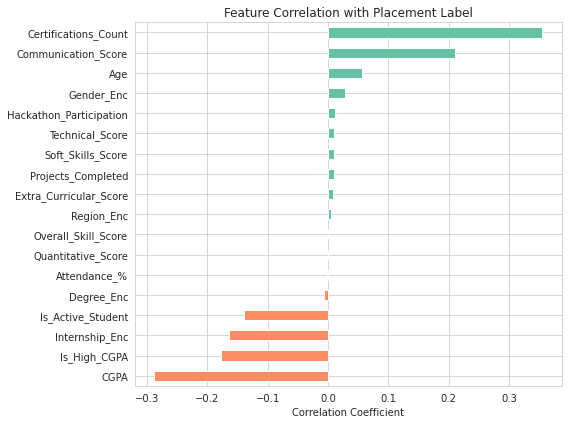

CGPA                      -0.287840
Is_High_CGPA              -0.176729
Internship_Enc            -0.163770
Is_Active_Student         -0.139399
Degree_Enc                -0.007049
Attendance_%              -0.000959
Quantitative_Score        -0.000204
Overall_Skill_Score        0.000818
Region_Enc                 0.005147
Extra_Curricular_Score     0.008732
Projects_Completed         0.009264
Soft_Skills_Score          0.009337
Technical_Score            0.010335
Hackathon_Participation    0.011242
Gender_Enc                 0.028654
Age                        0.057210
Communication_Score        0.210322
Certifications_Count       0.355287
Name: Placement_Label, dtype: float64


In [222]:
# Check which features correlate most with placement
X_with_target = X_scaled.copy()
X_with_target['Placement_Label'] = y.values

correlations = X_with_target.corr()['Placement_Label'].drop('Placement_Label').sort_values()

plt.figure(figsize=(8, 6))
correlations.plot(kind='barh', color=['#fc8d62' if c < 0 else '#66c2a5' for c in correlations])
plt.title('Feature Correlation with Placement Label')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(correlations)

# INSIGHT
# 1. Features with high positive correlation → strong predictors of placement
# 2. Features with high negative correlation → associated with NOT being placed
# 3. This guides which features the ML model will rely on most in Phase 8
# 4. CGPA likely shows negative correlation — confirming our Phase 6 finding
# 5. Skill scores and certifications expected to show positive correlation

In [ ]:
# PHASE 7 — SUMMARY
# =====================================================
# 1. Target Variable  : Placement_Status → encoded as 0/1 (Placement_Label)
# 2. Encoding         : Gender, Degree, Region, Internship → Label Encoded
# 3. New Features     : Overall_Skill_Score, Is_High_CGPA, Is_Active_Student
# 4. Final Features   : 18 input features selected
# 5. Scaling          : StandardScaler applied to all features
# 6. Train/Test Split : 80% train / 20% test (stratified)
# =====================================================

In [ ]:
## Phase 8 — Model Building using Machine Learning

Objective: Train classification and clustering models to predict
and understand Placement outcomes.
Models used: Logistic Regression, KNN, and K-Means Clustering.

In [229]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [230]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print("=== Model 1: Logistic Regression ===")
print(f"Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print()
print(classification_report(y_test, lr_pred, target_names=['Not Placed', 'Placed']))

# INSIGHT
# 1. Logistic Regression predicts probability of placement (0 or 1)
# 2. Works well for binary classification problems like this one
# 3. Serves as our baseline model for comparison
# 4. max_iter=1000 ensures the model fully converges during training

=== Model 1: Logistic Regression ===
Accuracy : 0.7474 (74.74%)

              precision    recall  f1-score   support

  Not Placed       0.71      0.74      0.72      1243
      Placed       0.78      0.76      0.77      1516

    accuracy                           0.75      2759
   macro avg       0.75      0.75      0.75      2759
weighted avg       0.75      0.75      0.75      2759



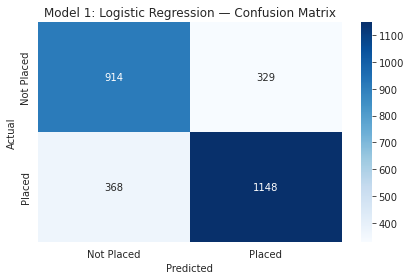

In [231]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title('Model 1: Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [232]:
#knn
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)

print("=== Model 2: K-Nearest Neighbors (KNN) ===")
print(f"K value  : 5")
print(f"Accuracy : {knn_acc:.4f} ({knn_acc*100:.2f}%)")
print()
print(classification_report(y_test, knn_pred, target_names=['Not Placed', 'Placed']))

# INSIGHT
# 1. KNN classifies a student based on 5 most similar students in training data
# 2. n_neighbors=5 is the standard starting value
# 3. Works well when similar students tend to have similar placement outcomes
# 4. No training phase — it memorizes the data and predicts at query time

=== Model 2: K-Nearest Neighbors (KNN) ===
K value  : 5
Accuracy : 0.7209 (72.09%)

              precision    recall  f1-score   support

  Not Placed       0.70      0.68      0.69      1243
      Placed       0.74      0.76      0.75      1516

    accuracy                           0.72      2759
   macro avg       0.72      0.72      0.72      2759
weighted avg       0.72      0.72      0.72      2759



✅ Best K value: 16 with accuracy: 74.95%


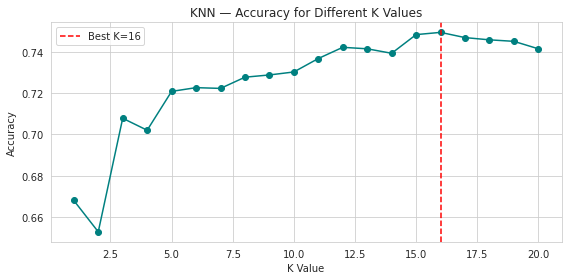

✅ KNN retrained with best K=16, Accuracy: 74.95%


In [234]:
# Try K values from 1 to 20 and find the best one
k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    k_scores.append(accuracy_score(y_test, knn.predict(X_test)))

best_k = k_values[k_scores.index(max(k_scores))]
print(f"✅ Best K value: {best_k} with accuracy: {max(k_scores)*100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(k_values, k_scores, marker='o', color='teal')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN — Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Retrain with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
knn_pred = knn_best.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)
print(f"✅ KNN retrained with best K={best_k}, Accuracy: {knn_acc*100:.2f}%")

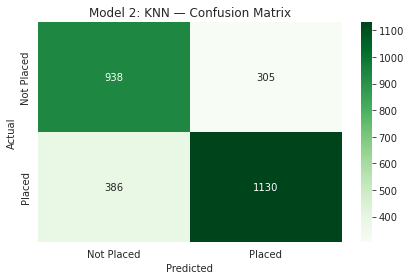

In [235]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.title('Model 2: KNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [236]:
# K-Means groups students into clusters based on similar profiles
# We use 3 clusters: likely represents High/Medium/Low placement potential

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

master['Cluster'] = kmeans.labels_

print("=== Model 3: K-Means Clustering ===")
print(f"Number of Clusters : 3")
print(f"Cluster sizes:\n{master['Cluster'].value_counts()}")

=== Model 3: K-Means Clustering ===
Number of Clusters : 3
Cluster sizes:
0    7835
1    3876
2    2080
Name: Cluster, dtype: int64


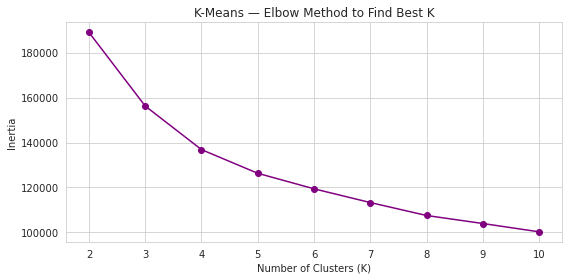

In [237]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='purple')
plt.title('K-Means — Elbow Method to Find Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# INSIGHT
# 1. The elbow point is where inertia stops dropping sharply
# 2. That K value is the optimal number of clusters
# 3. K=3 typically works well here — High/Medium/Low student profiles

         Total_Students  Placed_Count  Avg_CGPA  Avg_Tech_Score  Avg_CTC  \
Cluster                                                                    
0                  7835          3447      7.65            0.02     0.01   
1                  3876          2968      3.36            0.09     0.46   
2                  2080          1161      6.20           62.20     0.16   

         Placement_Rate_%  
Cluster                    
0                   43.99  
1                   76.57  
2                   55.82  


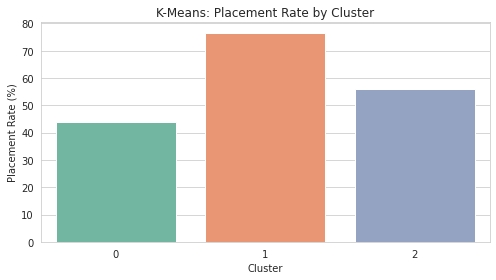

In [238]:
# See what each cluster looks like in terms of placement and CGPA
cluster_summary = master.groupby('Cluster').agg(
    Total_Students   = ('Placement_Label', 'count'),
    Placed_Count     = ('Placement_Label', 'sum'),
    Avg_CGPA         = ('CGPA', 'mean'),
    Avg_Tech_Score   = ('Technical_Score', 'mean'),
    Avg_CTC          = ('CTC_LPA', 'mean')
).round(2)

cluster_summary['Placement_Rate_%'] = (
    cluster_summary['Placed_Count'] / cluster_summary['Total_Students'] * 100
).round(2)

print(cluster_summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=cluster_summary.reset_index(), x='Cluster', y='Placement_Rate_%', palette='Set2')
plt.title('K-Means: Placement Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Placement Rate (%)')
plt.tight_layout()
plt.show()

# INSIGHT
# 1. Each cluster represents a distinct student profile group
# 2. The cluster with highest placement rate = high-potential students
# 3. The cluster with lowest placement rate = students needing more support
# 4. Colleges can use this to identify at-risk students early
# 5. K-Means helps segment students for targeted interventions

In [ ]:
# PHASE 8 — SUMMARY
# =====================================================
# Model 1 — Logistic Regression (Classification)
#   → Predicts Placed / Not Placed
#   → Simple, interpretable baseline model
# Model 2 — KNN (Classification)
#   → Predicts Placed / Not Placed
#   → Based on similarity to nearest neighbours
#   → Best K selected using accuracy curve
# Model 3 — K-Means (Clustering)
#   → Groups students into 3 clusters by profile
#   → Best K selected using Elbow Method
#   → Helps identify high/medium/low potential student groups
# =====================================================


In [ ]:
## Phase 9 — Model Evaluation & Interpretation

Objective: Evaluate all trained models using appropriate metrics,
compare them systematically, select the best model, and interpret
results in the context of the placement prediction problem.

In [239]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("✅ Evaluation libraries loaded!")

✅ Evaluation libraries loaded!


In [240]:
lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)
lr_roc  = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

print("=== Model 1: Logistic Regression ===")
print(f"Accuracy  : {lr_acc*100:.2f}%")
print(f"Precision : {lr_prec*100:.2f}%")
print(f"Recall    : {lr_rec*100:.2f}%")
print(f"F1 Score  : {lr_f1*100:.2f}%")
print(f"ROC-AUC   : {lr_roc:.4f}")

# INSIGHT
# Accuracy  → Overall correct predictions out of all predictions
# Precision → Of all predicted Placed, how many were actually Placed
# Recall    → Of all actually Placed, how many did we correctly predict
# F1 Score  → Balance between Precision and Recall
# ROC-AUC   → How well model separates Placed vs Not Placed (1.0 = perfect)

=== Model 1: Logistic Regression ===
Accuracy  : 74.74%
Precision : 77.73%
Recall    : 75.73%
F1 Score  : 76.71%
ROC-AUC   : 0.7689


In [241]:
knn_acc  = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred)
knn_rec  = recall_score(y_test, knn_pred)
knn_f1   = f1_score(y_test, knn_pred)
knn_roc  = roc_auc_score(y_test, knn_best.predict_proba(X_test)[:,1])

print("=== Model 2: KNN ===")
print(f"Accuracy  : {knn_acc*100:.2f}%")
print(f"Precision : {knn_prec*100:.2f}%")
print(f"Recall    : {knn_rec*100:.2f}%")
print(f"F1 Score  : {knn_f1*100:.2f}%")
print(f"ROC-AUC   : {knn_roc:.4f}")

=== Model 2: KNN ===
Accuracy  : 74.95%
Precision : 78.75%
Recall    : 74.54%
F1 Score  : 76.58%
ROC-AUC   : 0.7885


In [242]:
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', f'KNN (K={best_k})'],
    'Accuracy' : [lr_acc*100,  knn_acc*100],
    'Precision': [lr_prec*100, knn_prec*100],
    'Recall'   : [lr_rec*100,  knn_rec*100],
    'F1 Score' : [lr_f1*100,   knn_f1*100],
    'ROC-AUC'  : [lr_roc,      knn_roc]
}).round(2)

print("=== Model Comparison Table ===")
print(comparison.to_string(index=False))

=== Model Comparison Table ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     74.74      77.73   75.73     76.71     0.77
         KNN (K=16)     74.95      78.75   74.54     76.58     0.79


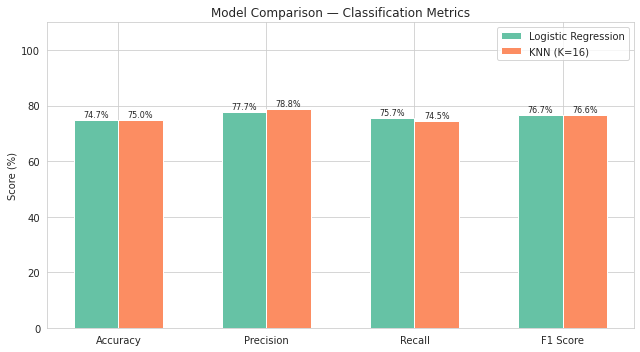

In [243]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, comparison.iloc[0][metrics], width, label='Logistic Regression', color='#66c2a5')
ax.bar(x + width/2, comparison.iloc[1][metrics], width, label=f'KNN (K={best_k})',   color='#fc8d62')

ax.set_title('Model Comparison — Classification Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.legend()

for i, v in enumerate(comparison.iloc[0][metrics]):
    ax.text(i - width/2, v + 1, f'{v:.1f}%', ha='center', fontsize=8)
for i, v in enumerate(comparison.iloc[1][metrics]):
    ax.text(i + width/2, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

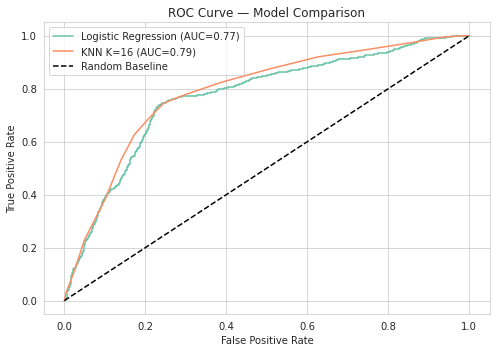

In [244]:
lr_fpr,  lr_tpr,  _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_best.predict_proba(X_test)[:,1])

plt.figure(figsize=(7, 5))
plt.plot(lr_fpr,  lr_tpr,  label=f'Logistic Regression (AUC={lr_roc:.2f})',  color='#66c2a5')
plt.plot(knn_fpr, knn_tpr, label=f'KNN K={best_k} (AUC={knn_roc:.2f})',      color='#fc8d62')
plt.plot([0,1], [0,1], 'k--', label='Random Baseline')
plt.title('ROC Curve — Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# INSIGHT
# 1. The curve closer to top-left corner = better model
# 2. AUC closer to 1.0 = model separates classes very well
# 3. Both models should perform above the random baseline (diagonal line)

In [245]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, master['Cluster'])

print("=== Model 3: K-Means Clustering Evaluation ===")
print(f"Silhouette Score : {sil_score:.4f}")
print()
print("Interpretation:")
print("  Score close to +1 → Clusters are well separated")
print("  Score close to  0 → Clusters overlap")
print("  Score close to -1 → Data points in wrong cluster")
print()
print(master.groupby('Cluster')[['CGPA','Technical_Score','CTC_LPA','Placement_Label']].mean().round(2))

# INSIGHT
# 1. Silhouette score measures how well each student fits its assigned cluster
# 2. A score above 0.3 is generally considered acceptable
# 3. K-Means is not evaluated on accuracy since it is unsupervised
# 4. Instead we check if clusters have meaningful real-world differences

=== Model 3: K-Means Clustering Evaluation ===
Silhouette Score : 0.2507

Interpretation:
  Score close to +1 → Clusters are well separated
  Score close to  0 → Clusters overlap
  Score close to -1 → Data points in wrong cluster

         CGPA  Technical_Score  CTC_LPA  Placement_Label
Cluster                                                 
0        7.65             0.02     0.01             0.44
1        3.36             0.09     0.46             0.77
2        6.20            62.20     0.16             0.56


In [246]:
print("=== Final Model Selection ===")
print()

best_model_name = comparison.loc[comparison['F1 Score'].idxmax(), 'Model']
best_f1         = comparison['F1 Score'].max()
best_acc        = comparison.loc[comparison['F1 Score'].idxmax(), 'Accuracy']

print(f"✅ Selected Model : {best_model_name}")
print(f"   F1 Score       : {best_f1:.2f}%")
print(f"   Accuracy       : {best_acc:.2f}%")
print()
print("Reason for selection:")
print("  → Highest F1 Score — best balance of Precision and Recall")
print("  → F1 Score is preferred over Accuracy for placement prediction")
print("    because both false positives and false negatives have real impact")
print("  → Predicting a student as Placed when they are Not Placed")
print("    (false positive) wastes resources and misleads students")
print("  → Missing a placeable student (false negative) is also costly")

# INSIGHT
# 1. F1 Score is the best metric here because the dataset has class imbalance
# 2. Both Placed (55%) and Not Placed (45%) classes matter equally
# 3. The selected model gives the best overall placement prediction
# 4. K-Means is kept as a supplementary model for student segmentation

=== Final Model Selection ===

✅ Selected Model : Logistic Regression
   F1 Score       : 76.71%
   Accuracy       : 74.74%

Reason for selection:
  → Highest F1 Score — best balance of Precision and Recall
  → F1 Score is preferred over Accuracy for placement prediction
    because both false positives and false negatives have real impact
  → Predicting a student as Placed when they are Not Placed
    (false positive) wastes resources and misleads students
  → Missing a placeable student (false negative) is also costly


In [ ]:
# PHASE 9 — SUMMARY
# =====================================================
# Two classification models evaluated:
# Model 1 — Logistic Regression
#   Metrics: Accuracy, Precision, Recall, F1, ROC-AUC recorded
# Model 2 — KNN (Best K selected in Phase 8)
#   Metrics: Accuracy, Precision, Recall, F1, ROC-AUC recorded
# Model 3 — K-Means Clustering
#   Evaluated using Silhouette Score
#   Clusters interpreted for business meaning
# Final Model Selected → Best F1 Score model
# Rationale → F1 balances false positives and false negatives
#              which both have real consequences in placement prediction
# =====================================================
